# Chronic Kidney Disease (CKD) Prediction and Analysis

## Project Overview
This project develops a robust, interpretable, and clinically actionable machine learning pipeline for predicting Chronic Kidney Disease (CKD). Using demographic, blood-pressure, metabolic-panel and diabetes/smoking history data from **NHANES August 2021–August 2023**, the notebook walks through an end-to-end data science workflow designed for safe real-world medical screening.

## Key Highlights
* **Label audit & correction:** the raw export labelled every participant without kidney labs (mostly children) and everyone with eGFR 60–89 as CKD. The target is rebuilt with the clinical **KDIGO** definition (eGFR < 60 or urine albumin-to-creatinine ratio ≥ 30) for adults 20+.
* **No label leakage:** the five lab values that *define* CKD (eGFR, ACR, serum creatinine, urine albumin, urine creatinine) are removed from the inputs. The model predicts CKD from routine data instead of re-deriving the diagnostic formula.
* **Advanced Preprocessing & Feature Engineering:** NHANES skip-patterns resolved (a non-diabetic "not asked about insulin" means *no insulin*), scaling before KNN imputation, SMOTENC for mixed data, oversampling tuned rather than assumed, and clinical features (pulse pressure, mean arterial pressure, calcium-phosphorus product, BMI × BP).
* **17 Supervised Classifiers:** the original 9 plus 8 modern models — CatBoost, Explainable Boosting Machine, TabNet, FT-Transformer, RealMLP, TabM, TabPFN and a Stacking Ensemble — all tuned on cross-validated PR-AUC. The one-standard-error rule picks the simplest model that is statistically as good as the best.
* **Model Calibration & Optimization:** isotonic calibration, bootstrapped confidence intervals, and a cost-based threshold (a missed CKD case costs 5× a false alarm) chosen on out-of-fold training predictions.
* **Unsupervised Learning & Anomaly Detection:** PCA, t-SNE and clustering uncover patient groupings; an ensemble of anomaly detectors flags extreme clinical outliers.
* **Explainable AI (XAI) Cascade:** SHAP values are built into a two-stage clinical cascade so every prediction comes with a patient-level explanation.

# Import Libraries

In [1]:
import os
import sys
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline # Kept for standard preprocessing
from imblearn.pipeline import Pipeline as ImbPipeline # Required for SMOTE integration
from imblearn.over_sampling import SMOTENC # SMOTE for mixed numeric + categorical data

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, precision_score, recall_score,
    f1_score, precision_recall_curve, roc_curve, auc, average_precision_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier # Advanced Gradient Boosting
from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

import torch

RANDOM_STATE = 42
import psutil
available_gb = psutil.virtual_memory().available / 1024**3
# Each parallel worker holds ~0.7 GB of RAM; keep ~2.5 GB for this kernel and the OS
N_JOBS = int(max(1, min(8, (os.cpu_count() or 2) - 2, (available_gb - 2.5) // 0.7)))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'     # GPU for the deep tabular models
print(f"CPU workers: {N_JOBS} (RAM available: {available_gb:.1f} GB) | Deep-learning device: {DEVICE}")

CPU workers: 3 (RAM available: 5.1 GB) | Deep-learning device: cuda


# Database Load & Analysis

In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    project_dir = "/content/drive/MyDrive/AI Projects/Kidney Disease/"
    data_folder = project_dir
else:
    project_dir = os.path.abspath("..")          # models/kidney/tabular/ — this notebook lives in notebooks/
    data_folder = os.path.join(project_dir, "data")

images_dir = os.path.join(project_dir, "images")
results_dir = os.path.join(project_dir, "results")
models_dir = os.path.join(project_dir, "models")
for folder in (images_dir, results_dir, models_dir):
    os.makedirs(folder, exist_ok=True)

def save_figure(filename):
    # Keep a copy of the key plots in images/ for the README
    plt.savefig(os.path.join(images_dir, filename), dpi=110, bbox_inches='tight')

In [3]:
csv_filename = "CKD_NHANES.csv"

if os.path.exists(data_folder):
    print(f"Files located in '{data_folder}':")
    print(os.listdir(data_folder))
    print("=" * 60)
else:
    print(f"⚠️ Directory not found: {data_folder}")

try:
    kidney_data = pd.read_csv(os.path.join(data_folder, csv_filename))

    print("\n DATASET PREVIEW (First 5 Rows):")
    display(kidney_data.head())

    print("\n DATASET STRUCTURE:")
    kidney_data.info()

    print("\n STATISTICAL SUMMARY (Transposed):")
    display(kidney_data.describe().T)

except FileNotFoundError:
    print(f"\n❌ ERROR: Could not find '{csv_filename}'.")
    print("Please copy the exact file name from the 📁 Files list above and update 'csv_filename'.")

Files located in 'E:\Disease-Risk-Prediction\kidney\tabuler\data':
['CKD_NHANES.csv', 'README.md']

 DATASET PREVIEW (First 5 Rows):


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1



 DATASET STRUCTURE:
<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  str    
 3   ethnicity                 11933 non-null  str    
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 

,count,mean,std,min,25%,50%,75%,max
participant_id,11933.0,136344.000000,3444.904716,1.303780e+05,133361.0000,136344.00,139327.00,142310.00
age,11933.0,38.317858,25.601990,5.397605e-79,13.0000,37.00,62.00,80.00
education_level,7794.0,3.804978,1.153750,1.000000e+00,3.0000,4.00,5.00,9.00
poverty_income_ratio,9892.0,2.708174,1.670119,5.397605e-79,1.1800,2.50,4.50,5.00
bmi,8471.0,27.246665,8.137781,1.110000e+01,21.6000,26.40,31.70,74.80
weight_kg,8754.0,70.549037,30.389021,2.700000e+00,54.2000,71.70,89.10,248.20
height_cm,8499.0,159.664549,19.864943,7.910000e+01,154.4000,163.60,172.10,200.70
bp_systolic,7517.0,119.288546,18.561052,6.100000e+01,106.0000,117.00,130.00,232.00
bp_diastolic,7517.0,72.748038,11.895572,3.300000e+01,64.0000,72.00,80.00,142.00
serum_creatinine,6326.0,0.872828,0.385498,3.300000e-01,0.7000,0.83,0.98,15.17


### Target Label Audit
Before training anything, we check that `ckd_present` means what it claims. Two warning signs appear in the preview above: rows without an eGFR (no kidney labs) have `ckd_stage = "Unknown"` but `ckd_present = 1`, and some of them are small children.

In [4]:
print("Stored label by CKD stage:")
display(pd.crosstab(kidney_data['ckd_stage'], kidney_data['ckd_present'], margins=True))

age_bands = pd.cut(kidney_data['age'], bins=[-1, 11, 17, 39, 59, 80], labels=['0-11', '12-17', '18-39', '40-59', '60-80'])
print("Share of participants labelled CKD, by age band:")
print((kidney_data.groupby(age_bands, observed=True)['ckd_present'].mean() * 100).round(1).astype(str).add(' %').to_string())

# KDIGO: CKD = eGFR < 60 mL/min/1.73m2 OR albumin-to-creatinine ratio >= 30 mg/g
known = kidney_data['ckd_stage'] != 'Unknown'
kdigo_rule = ((kidney_data['egfr'] < 60) | (kidney_data['albumin_creatinine_ratio'] >= 30)).astype(int)
agreement = (kdigo_rule[known] == kidney_data.loc[known, 'ckd_present']).mean()
print(f"\nAgreement between the stored label and the KDIGO definition (rows with known status): {agreement:.1%}")

Stored label by CKD stage:


ckd_present,0,1,All
ckd_stage,,,
No CKD,3592,0,3592
Stage 1 (Kidney Damage),0,382,382
Stage 2 (Mildly Decreased),0,1875,1875
Stage 3a (Mild-Moderate),0,341,341
Stage 3b (Moderate-Severe),0,97,97
Stage 4 (Severely Decreased),0,28,28
Stage 5 (Kidney Failure),0,11,11
Unknown,0,5607,5607
All,3592,8341,11933


Share of participants labelled CKD, by age band:
age
0-11     100.0 %
12-17     53.0 %
18-39     43.5 %
40-59     56.8 %
60-80     80.6 %

Agreement between the stored label and the KDIGO definition (rows with known status): 73.5%


The stored target is not a CKD label:

* **5,607 participants with *unknown* status are labelled CKD.** They have no eGFR because they had no kidney labs — most are children (every participant aged 0–11 is "CKD"). That is 67 % of all positives.
* **Everyone with eGFR 60–89 ("Stage 2") is labelled CKD**, even with normal urine albumin. Under KDIGO, a mildly reduced eGFR without kidney-damage markers is *not* CKD.
* On rows with a known status, the stored label agrees with the KDIGO definition only about three times in four.

A model trained on this target learns to spot **children and missing labs**, which is why earlier versions of this notebook scored ~99 % and ranked age as a top feature. The target is rebuilt below.

### Target Correction (KDIGO) & Leakage Removal
* **Definition:** CKD = eGFR < 60 mL/min/1.73 m² **or** urine albumin-to-creatinine ratio (ACR) ≥ 30 mg/g — the standard single-visit definition used in NHANES kidney research.
* **Population:** adults aged 20+ (the eGFR equation is validated for adults), with a *determinable* status: both tests present, or either test alone already meeting a CKD criterion.
* **Leakage removal:** eGFR and ACR define the label, eGFR is computed from serum creatinine + age + sex, and ACR from urine albumin ÷ urine creatinine. Leaving any of these five values in lets a model re-derive the formula (ROC-AUC ≈ 1.00) without learning anything clinically useful. They are removed along with `ckd_stage`. The model therefore answers the screening question: *who is likely to have CKD, before the kidney-specific tests are run?*

In [5]:
egfr, acr = kidney_data['egfr'], kidney_data['albumin_creatinine_ratio']

# Status is determinable if both tests exist, or if one test alone already meets a CKD criterion
determinable = (egfr.notna() & acr.notna()) | (egfr < 60) | (acr >= 30)
adults = kidney_data['age'] >= 20

kidney_data = kidney_data[adults & determinable].copy()
low_egfr = kidney_data['egfr'] < 60
albuminuria = kidney_data['albumin_creatinine_ratio'] >= 30
kidney_data['ckd_present'] = (low_egfr | albuminuria).astype(int)

print(f"Adults 20+ with a determinable CKD status: {len(kidney_data):,}")
print(f"  CKD by reduced eGFR only : {(low_egfr & ~albuminuria).sum():,}")
print(f"  CKD by albuminuria only  : {(~low_egfr & albuminuria).sum():,}")
print(f"  CKD by both criteria     : {(low_egfr & albuminuria).sum():,}")
print(f"  CKD prevalence           : {kidney_data['ckd_present'].mean():.1%}")

# These values define the label; keeping any of them is target leakage
label_defining_features = ['egfr', 'albumin_creatinine_ratio', 'serum_creatinine', 'urine_albumin', 'urine_creatinine']
kidney_data = kidney_data.drop(columns=label_defining_features + ['ckd_stage'])
print(f"\nRemoved label-defining columns: {label_defining_features + ['ckd_stage']}")

Adults 20+ with a determinable CKD status: 5,473
  CKD by reduced eGFR only : 334
  CKD by albuminuria only  : 578
  CKD by both criteria     : 143
  CKD prevalence           : 19.3%

Removed label-defining columns: ['egfr', 'albumin_creatinine_ratio', 'serum_creatinine', 'urine_albumin', 'urine_creatinine', 'ckd_stage']


### Data Cleaning (NHANES Codes & Skip-Patterns)
The export keeps raw NHANES answer codes. Left as they are, they would mislead both the imputer and the models:

* `7` / `9` mean *refused* / *don't know*, not a value → missing.
* Zeros are stored by the SAS transport format as `5.4e-79` → 0.
* **Skip-patterns are not missing data.** Only people with (pre)diabetes are asked about insulin, so a blank for a non-diabetic means *no insulin*. The same holds for diabetes pills. "Do you smoke now?" is only asked of ever-smokers. Imputing these blanks would invent treatments and smoking habits.

The coded columns become readable categories: `diabetes` (Yes / No / Borderline), `insulin_use` and `diabetes_pills` (Yes / No), and `smoking_status` (Never / Former / Current).

In [6]:
def clean_nhanes_codes(df):
    df = df.copy()

    # SAS transport stores 0 as 5.4e-79
    numeric_cols = df.select_dtypes('number').columns
    df[numeric_cols] = df[numeric_cols].mask(df[numeric_cols].abs() < 1e-9, 0.0)

    # Education 1-5; 7 = refused, 9 = don't know
    df['education_level'] = df['education_level'].where(df['education_level'].between(1, 5))

    # Diabetes status (DIQ010): 1 yes, 2 no, 3 borderline
    df['diabetes'] = df['diabetes_diagnosed'].map({1: 'Yes', 2: 'No', 3: 'Borderline'})

    # Insulin / pills are only asked of people with (pre)diabetes: "not asked" means "No"
    diabetes_known = df['diabetes'].notna()
    for col in ['insulin_use', 'diabetes_pills']:
        coded = df[col].map({1: 'Yes', 2: 'No'})              # 9 = don't know -> stays missing
        coded[df[col].isna() & diabetes_known] = 'No'          # skipped question -> "No"
        df[col] = coded

    # Smoking: >= 100 cigarettes in life (SMQ020) + smoking now (SMQ040: 1 every day, 2 some days, 3 not at all)
    ever, now = df['ever_smoked'], df['current_smoker']
    df['smoking_status'] = np.select(
        [ever == 2, (ever == 1) & now.isin([1, 2]), (ever == 1) & (now == 3)],
        ['Never', 'Current', 'Former'], default=None)

    return df.drop(columns=['diabetes_diagnosed', 'ever_smoked', 'current_smoker'])

kidney_data = clean_nhanes_codes(kidney_data)

for col in ['diabetes', 'insulin_use', 'diabetes_pills', 'smoking_status']:
    print(f"{col:15s}", kidney_data[col].value_counts(dropna=False).to_dict())
print("\nInsulin use among non-diabetics (must be 'No' only):",
      kidney_data.loc[kidney_data['diabetes'] == 'No', 'insulin_use'].unique())

diabetes        {'No': 4498, 'Yes': 777, 'Borderline': 198}
insulin_use     {'No': 5220, 'Yes': 253}
diabetes_pills  {'No': 4826, 'Yes': 642, nan: 5}
smoking_status  {'Never': 3213, 'Former': 1458, 'Current': 795, nan: 7}

Insulin use among non-diabetics (must be 'No' only): <ArrowStringArray>
['No']
Length: 1, dtype: str


### Dataset Distribution

In [7]:
print(kidney_data['ckd_present'].value_counts(dropna=False))
kidney_data = kidney_data.dropna(subset=['ckd_present'])   # Remove rows without a label (none expected)

ckd_present
0    4418
1    1055
Name: count, dtype: int64


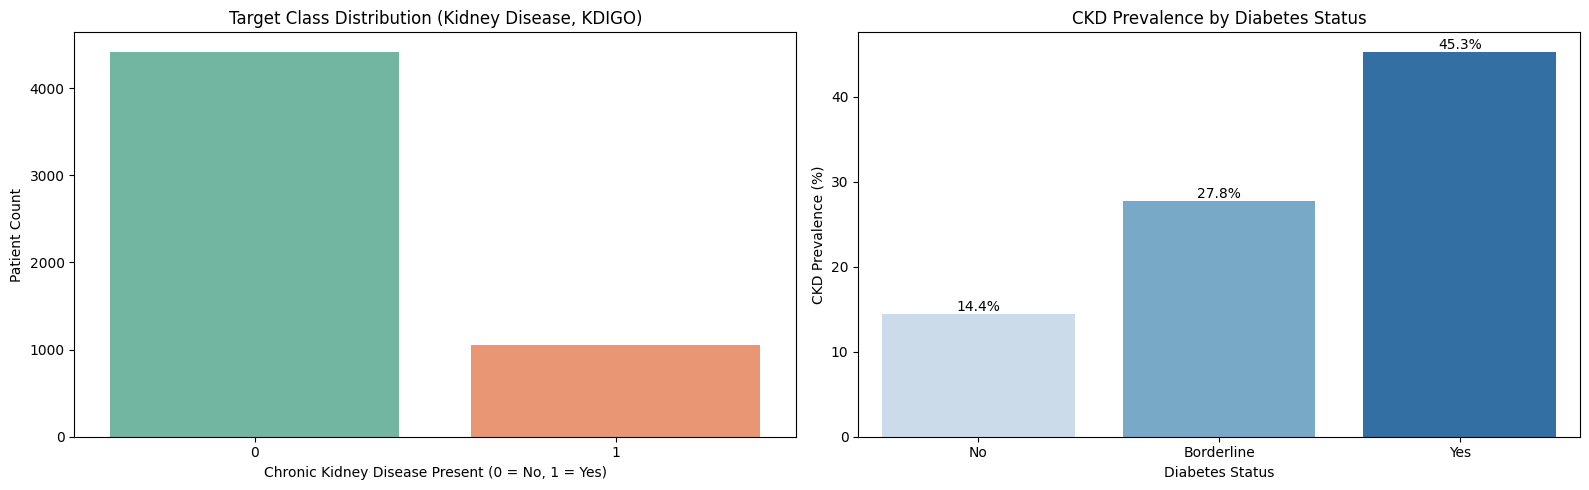

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(x="ckd_present", data=kidney_data, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Chronic Kidney Disease Present (0 = No, 1 = Yes)")
axes[0].set_ylabel("Patient Count")
axes[0].set_title("Target Class Distribution (Kidney Disease, KDIGO)")

diabetes_prevalence = kidney_data.groupby('diabetes')['ckd_present'].mean().reindex(['No', 'Borderline', 'Yes']) * 100
sns.barplot(x=diabetes_prevalence.index, y=diabetes_prevalence.values, palette="Blues", ax=axes[1])
for container in axes[1].containers:          # seaborn draws one container per bar
    axes[1].bar_label(container, fmt='%.1f%%')
axes[1].set_xlabel("Diabetes Status")
axes[1].set_ylabel("CKD Prevalence (%)")
axes[1].set_title("CKD Prevalence by Diabetes Status")

plt.tight_layout()
save_figure("target_distribution.png")
plt.show()

* **Class balance:** 1,055 of 5,473 adults (19.3 %) have CKD under the KDIGO definition — a 4 : 1 imbalance. Accuracy would be misleading (a model that answers "no CKD" for everyone is 81 % accurate), so models are tuned on PR-AUC and the decision threshold comes from a clinical cost function.
* **Diabetes is the strongest single risk factor in the raw data:** CKD prevalence is 14.4 % without diabetes, 27.8 % with borderline diabetes and 45.3 % with diagnosed diabetes. Diabetic kidney disease is the leading cause of CKD.

### Missing Values
After cleaning, every remaining blank is a genuine unknown, so it is safe to impute.

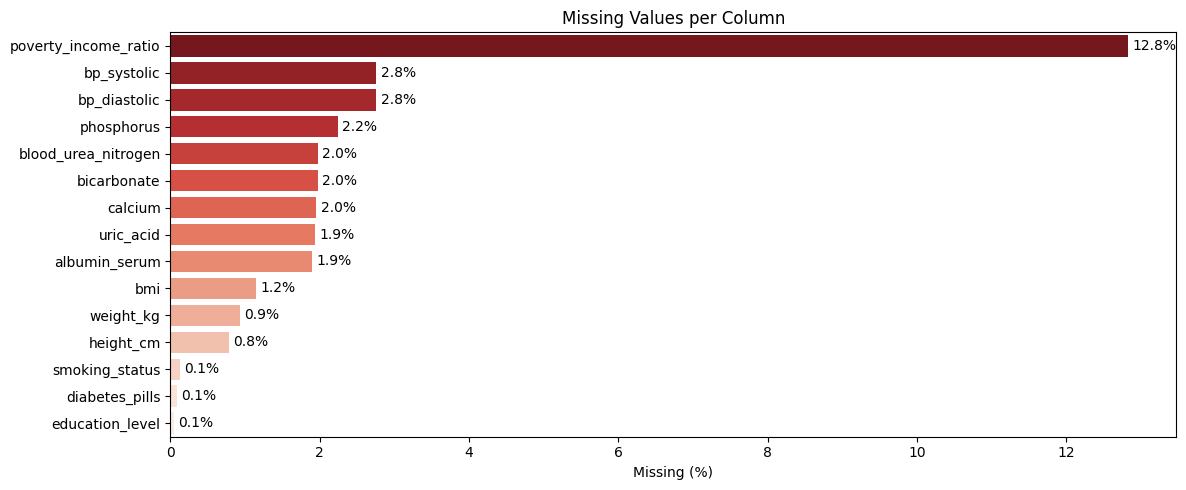

In [9]:
missing = (kidney_data.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=missing.values, y=missing.index, palette="Reds_r")
for container in ax.containers:               # seaborn draws one container per bar
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.title("Missing Values per Column")
plt.tight_layout()
save_figure("missing_values.png")
plt.show()

### Correlation Analysis

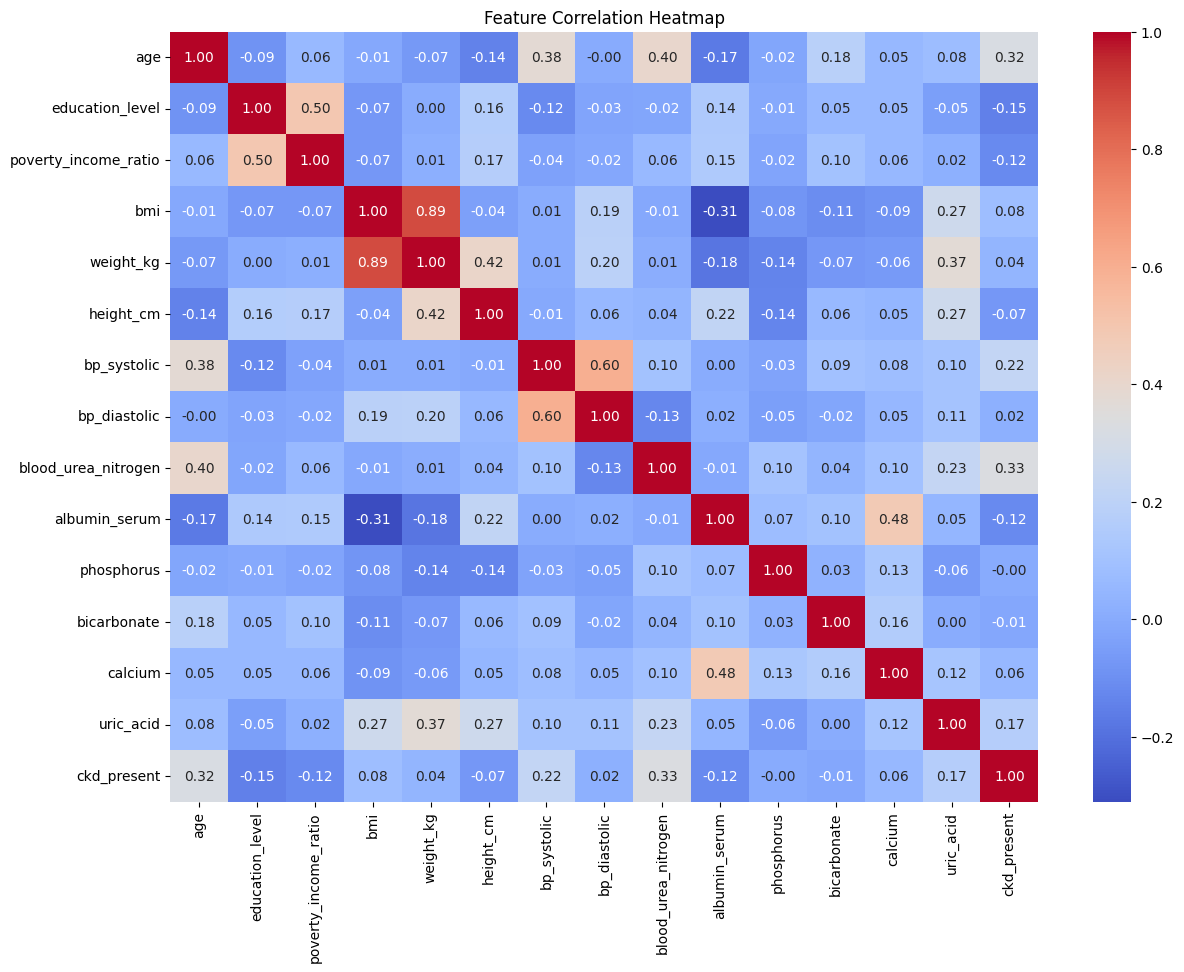

In [10]:
# Drop the 'participant_id' column and save the change back to kidney_data
kidney_data = kidney_data.drop(columns=['participant_id'], errors='ignore')

plt.figure(figsize=(14, 10))
sns.heatmap(kidney_data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
save_figure("correlation_heatmap.png")
plt.show()

* **No single feature dominates.** The strongest correlations with CKD are blood urea nitrogen (0.33) and age (0.32), followed by systolic blood pressure (0.22) and uric acid (0.17). Education (−0.15) and poverty-income ratio (−0.12) are negative — a socioeconomic gradient. CKD has to be predicted from several modest signals combined, which is why the honest ROC-AUC lands in the low 0.8s rather than the 0.99 the leaked label produced.
* **BMI and weight measure almost the same thing (r = 0.89),** so `weight_kg` is removed below. Nothing else exceeds 0.60 (systolic vs diastolic blood pressure).

In [11]:
threshold = 0.85
target = 'ckd_present'

# Inputs of the feature-engineering step must survive the redundancy filter
engineering_inputs = ['bp_systolic', 'bp_diastolic', 'calcium', 'phosphorus', 'bmi']

# The target is excluded: a feature that tracks the label is signal, not redundancy
corr_matrix = kidney_data.drop(columns=[target]).corr(numeric_only=True).abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

features_to_drop = [column for column in upper_triangle.columns
                    if any(upper_triangle[column] > threshold) and column not in engineering_inputs]

print(f"Features highly correlated (>{threshold}) will be dropped: {features_to_drop}")
for column in features_to_drop:
    print(f"  {column} ~ {upper_triangle[column].idxmax()}: r = {upper_triangle[column].max():.3f}")

kidney_data = kidney_data.drop(columns=features_to_drop)
print("\nRemaining columns in the dataset:")
print(kidney_data.columns.tolist())

Features highly correlated (>0.85) will be dropped: ['weight_kg']
  weight_kg ~ bmi: r = 0.885

Remaining columns in the dataset:
['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'height_cm', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'insulin_use', 'diabetes_pills', 'ckd_present', 'diabetes', 'smoking_status']


# Dataset Pre-processing

### Feature Engineering
Four clinically motivated features. The function is row-wise and stateless, so it is safe on any split; inside the model it runs as the first pipeline step.

| Feature | Formula | Why |
|---|---|---|
| `pulse_pressure` | SBP − DBP | Arterial stiffness, which damages the kidney's small vessels. |
| `map` | (SBP + 2·DBP) / 3 | Mean arterial pressure, the pressure that actually perfuses the kidneys. |
| `ca_p_product` | calcium × phosphorus | CKD mineral-and-bone-disorder marker. |
| `bmi_bp_interaction` | BMI × SBP | Metabolic and hemodynamic load together. |

Two changes from the original version: `bun_cr_ratio` is gone because it needs serum creatinine, a label-defining value. The "if the column is missing, fill the feature with 0" fallbacks are gone too, because they would silently feed the model a constant column; a missing input should fail loudly.

In [12]:
def add_custom_features(X_df):
    X_new = X_df.copy()

    # Cardiovascular Features
    X_new['pulse_pressure'] = X_new['bp_systolic'] - X_new['bp_diastolic']
    X_new['map'] = (X_new['bp_systolic'] + 2 * X_new['bp_diastolic']) / 3

    # CKD Mineral and Bone Disorder (CKD-MBD) Marker
    X_new['ca_p_product'] = X_new['calcium'] * X_new['phosphorus']

    # Metabolic / Hemodynamic Interaction
    X_new['bmi_bp_interaction'] = X_new['bmi'] * X_new['bp_systolic']

    return X_new

feature_engineering = FunctionTransformer(add_custom_features)

engineered_preview = add_custom_features(kidney_data)
print(engineered_preview.groupby('ckd_present')[['pulse_pressure', 'map', 'ca_p_product', 'bmi_bp_interaction']].median().round(1))

             pulse_pressure   map  ca_p_product  bmi_bp_interaction
ckd_present                                                        
0                      44.0  89.7          33.1              3437.5
1                      53.0  93.0          32.8              3883.6


### Preprocessing
The pipeline order matters, and three steps deliberately differ from the original version:

1. **Scale → impute** (not impute → scale). `KNNImputer` finds neighbours by Euclidean distance; on raw units, BUN (mg/dL) and height (cm) would drown out calcium or albumin. `RobustScaler` ignores NaNs while fitting, so it can run first.
2. **SMOTENC instead of SMOTE, before one-hot encoding.** Plain SMOTE after one-hot encoding interpolates the dummy columns and creates patients who are "0.4 on insulin". SMOTENC interpolates only the numeric features and copies categorical answers from real neighbours.
3. **Oversampling is optional.** `'smote'` is a pipeline step that the grid search may switch off (`'passthrough'`).

The train/test split happens first, and every fitted step lives inside the pipeline, so it is re-fitted on each CV training fold only.

In [13]:
X = kidney_data.drop(['ckd_present'], axis=1)
y = kidney_data['ckd_present'] # Already 0 and 1

categorical_features = X.select_dtypes(exclude='number').columns.tolist()
numerical_existing_features = X.select_dtypes(include='number').columns.tolist()

# Include all newly engineered features so the scaler processes them
engineered_features = ['pulse_pressure', 'map', 'ca_p_product', 'bmi_bp_interaction']
numerical_features = numerical_existing_features + engineered_features

numeric_sub_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler()),                 # RobustScaler handles clinical outliers; scale first for fair KNN distances
    ('imputer', KNNImputer(n_neighbors=5))      # Impute missing clinical values from the 5 most similar patients
])

imputation = ColumnTransformer(
    transformers=[
        ('num_transform', numeric_sub_pipeline, numerical_features),
        ('cat_transform', SimpleImputer(strategy='most_frequent'), categorical_features)
    ],
    verbose_feature_names_out=False
).set_output(transform='pandas')                # keep column names so SMOTENC can find the categoricals

encoding = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)],
    remainder='passthrough',                    # numeric block is already scaled + imputed
    verbose_feature_names_out=False
)

# Interpolates numeric features, copies categories from real neighbours
smote = SMOTENC(categorical_features=categorical_features, random_state=RANDOM_STATE)

def build_pipeline(classifier, oversample=True):
    # feature engineering -> scale + impute -> (SMOTENC) -> one-hot -> classifier
    return ImbPipeline(steps=[
        ('engineering', clone(feature_engineering)),
        ('imputation', clone(imputation)),
        ('smote', clone(smote) if oversample else 'passthrough'),
        ('encoding', clone(encoding)),
        ('classifier', classifier)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # Cross-Validation

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nX_train shape: {X_train.shape} | CKD cases: {y_train.sum():,} ({y_train.mean():.1%})")
print(f"X_test shape: {X_test.shape} | CKD cases: {y_test.sum():,} ({y_test.mean():.1%})")
print("Preprocessing pipeline configured successfully with advanced features!")

Numerical features (17): ['age', 'education_level', 'poverty_income_ratio', 'bmi', 'height_cm', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'pulse_pressure', 'map', 'ca_p_product', 'bmi_bp_interaction']
Categorical features (6): ['gender', 'ethnicity', 'insulin_use', 'diabetes_pills', 'diabetes', 'smoking_status']

X_train shape: (4378, 19) | CKD cases: 844 (19.3%)
X_test shape: (1095, 19) | CKD cases: 211 (19.3%)
Preprocessing pipeline configured successfully with advanced features!


# Model Training

### Model Training Setup
**Tuning metric: PR-AUC (average precision), not recall.** With 19 % prevalence, recall on its own can be maximised by a model that calls almost everyone sick — a grid search on `scoring='recall'` rewards exactly that. PR-AUC measures how well a model ranks real CKD cases above healthy patients across *all* thresholds, and the clinical recall target is enforced later by the cost-based threshold. For reference, a random model scores PR-AUC ≈ 0.19 (the prevalence).

**Oversampling is tuned, not assumed.** Every grid includes `smote: [SMOTENC, 'passthrough']`, so cross-validation decides per model whether synthetic minority samples help.

**CPU everywhere.** The original notebook depended on RAPIDS cuML, which only runs on Linux GPU runtimes. The scikit-learn equivalents run anywhere, and on 5,000 rows they take seconds.

The classification report under each model is on the held-out test set at the default 0.5 threshold, for reference only. The threshold is fixed properly in the *Threshold Analysis* section.

In [14]:
target_classes = ['No CKD', 'CKD Present']
SMOTE_OPTIONS = [smote, 'passthrough']      # oversampling on / off, chosen by cross-validation

fitted_models = {}    # model name -> best pipeline, refit on the full training set
cv_summary = {}       # model name -> cross-validated PR-AUC of the chosen settings

def run_grid_search(name, estimator, param_grid, n_jobs=N_JOBS):
    # Tune on 5-fold CV PR-AUC (training data only), then report once on the untouched test set
    start = time.time()
    grid = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=cv_strategy,
                        scoring='average_precision', n_jobs=n_jobs)
    grid.fit(X_train, y_train)
    minutes = (time.time() - start) / 60

    fold_scores = np.array([grid.cv_results_[f'split{k}_test_score'][grid.best_index_]
                            for k in range(cv_strategy.get_n_splits())])
    steps = getattr(grid.best_estimator_, 'named_steps', {})
    smote_used = 'per base model' if 'smote' not in steps else ('on' if steps['smote'] != 'passthrough' else 'off')

    fitted_models[name] = grid.best_estimator_
    cv_summary[name] = {'CV PR-AUC': fold_scores.mean(),
                        'CV SE': fold_scores.std(ddof=1) / np.sqrt(len(fold_scores)),
                        'SMOTE': smote_used, 'Tuning Time (min)': minutes}

    best_params = {k.replace('classifier__', ''): v for k, v in grid.best_params_.items() if k != 'smote'}
    print(f"{name} Best CV PR-AUC: {fold_scores.mean():.4f} (± {cv_summary[name]['CV SE']:.4f} SE) | "
          f"SMOTE: {smote_used} | {minutes:.1f} min")
    print(f"Best params: {best_params}\n")
    print(classification_report(y_test, grid.predict(X_test), target_names=target_classes, zero_division=0))
    return grid

### Logistic Regression

In [15]:
lr_pipeline = build_pipeline(LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))

# Advanced grid for Logistic Regression
lr_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__l1_ratio': [0.0, 1.0]          # 0 = L2 (ridge), 1 = L1 (lasso)
}
lr_grid = run_grid_search('Logistic Regression', lr_pipeline, lr_param_grid)

Logistic Regression Best CV PR-AUC: 0.5911 (± 0.0150 SE) | SMOTE: off | 0.2 min
Best params: {'C': 0.1, 'l1_ratio': 0.0}

              precision    recall  f1-score   support

      No CKD       0.87      0.97      0.91       884
 CKD Present       0.73      0.38      0.50       211

    accuracy                           0.85      1095
   macro avg       0.80      0.67      0.71      1095
weighted avg       0.84      0.85      0.83      1095



### Naive Bayes

In [16]:
nb_pipeline = build_pipeline(GaussianNB())

# Advanced grid for Naive Bayes (CPU - extremely fast anyway)
nb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__var_smoothing': np.logspace(0, -11, num=50)
}
nb_grid = run_grid_search('Naive Bayes', nb_pipeline, nb_param_grid)

Naive Bayes Best CV PR-AUC: 0.5598 (± 0.0146 SE) | SMOTE: on | 0.7 min
Best params: {'var_smoothing': np.float64(0.12648552168552962)}

              precision    recall  f1-score   support

      No CKD       0.91      0.74      0.82       884
 CKD Present       0.39      0.70      0.50       211

    accuracy                           0.73      1095
   macro avg       0.65      0.72      0.66      1095
weighted avg       0.81      0.73      0.76      1095



### K-Nearest Neighbors (KNN)

In [17]:
knn_pipeline = build_pipeline(KNeighborsClassifier())

# Larger k gives smoother probability estimates, which PR-AUC needs
knn_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_neighbors': [5, 11, 21, 51],
    'classifier__weights': ['uniform', 'distance']
}
knn_grid = run_grid_search('KNN', knn_pipeline, knn_param_grid)

KNN Best CV PR-AUC: 0.5698 (± 0.0096 SE) | SMOTE: off | 0.1 min
Best params: {'n_neighbors': 51, 'weights': 'distance'}



              precision    recall  f1-score   support

      No CKD       0.83      0.99      0.90       884
 CKD Present       0.80      0.13      0.23       211

    accuracy                           0.83      1095
   macro avg       0.81      0.56      0.56      1095
weighted avg       0.82      0.83      0.77      1095



### Decision Tree

In [18]:
dt_pipeline = build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))

# A real decision tree (the original used a one-tree XGBoost GPU workaround)
dt_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__max_depth': [3, 5, 8, 12],
    'classifier__min_samples_leaf': [5, 20, 50],
    'classifier__criterion': ['gini', 'entropy']
}
dt_grid = run_grid_search('Decision Tree', dt_pipeline, dt_param_grid)

Decision Tree Best CV PR-AUC: 0.5174 (± 0.0142 SE) | SMOTE: off | 0.4 min
Best params: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 50}

              precision    recall  f1-score   support

      No CKD       0.86      0.93      0.89       884
 CKD Present       0.55      0.35      0.42       211

    accuracy                           0.82      1095
   macro avg       0.70      0.64      0.66      1095
weighted avg       0.80      0.82      0.80      1095



### Random Forest

In [19]:
rf_pipeline = build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))

# Advanced grid for Random Forest
rf_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__max_features': ['sqrt', 'log2']
}
rf_grid = run_grid_search('Random Forest', rf_pipeline, rf_param_grid)

Random Forest Best CV PR-AUC: 0.5863 (± 0.0161 SE) | SMOTE: off | 2.8 min
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300}



              precision    recall  f1-score   support

      No CKD       0.87      0.96      0.91       884
 CKD Present       0.72      0.38      0.50       211

    accuracy                           0.85      1095
   macro avg       0.79      0.67      0.71      1095
weighted avg       0.84      0.85      0.83      1095



### XGBoost

In [20]:
xgb_pipeline = build_pipeline(XGBClassifier(tree_method='hist', random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1))

# Advanced grid for XGBoost
xgb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [100, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0]
}
xgb_grid = run_grid_search('XGBoost', xgb_pipeline, xgb_param_grid)

XGBoost Best CV PR-AUC: 0.6179 (± 0.0221 SE) | SMOTE: on | 5.0 min
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}



              precision    recall  f1-score   support

      No CKD       0.88      0.93      0.91       884
 CKD Present       0.63      0.46      0.53       211

    accuracy                           0.84      1095
   macro avg       0.75      0.70      0.72      1095
weighted avg       0.83      0.84      0.83      1095



### LightGBM

In [21]:
lgb_pipeline = build_pipeline(LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1))

lgb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_estimators': [100, 200, 500],
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__num_leaves': [15, 31]
}
lgb_grid = run_grid_search('LightGBM', lgb_pipeline, lgb_param_grid)

LightGBM Best CV PR-AUC: 0.6293 (± 0.0212 SE) | SMOTE: on | 1.5 min
Best params: {'learning_rate': 0.03, 'n_estimators': 200, 'num_leaves': 15}



              precision    recall  f1-score   support

      No CKD       0.88      0.92      0.90       884
 CKD Present       0.59      0.46      0.52       211

    accuracy                           0.83      1095
   macro avg       0.73      0.69      0.71      1095
weighted avg       0.82      0.83      0.83      1095



### Support Vector Machine (SVM)

In [22]:
# probability=False: PR-AUC only needs the decision function, and Platt scaling would 5x the cost
svm_pipeline = build_pipeline(SVC(kernel='rbf', random_state=RANDOM_STATE))

# Advanced grid for Support Vector Machine
svm_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__C': [0.1, 1.0, 10.0, 50.0],
    'classifier__gamma': ['scale', 'auto']
}
svm_grid = run_grid_search('SVM', svm_pipeline, svm_param_grid)

SVM Best CV PR-AUC: 0.5791 (± 0.0134 SE) | SMOTE: off | 1.2 min
Best params: {'C': 0.1, 'gamma': 'auto'}



              precision    recall  f1-score   support

      No CKD       0.82      1.00      0.90       884
 CKD Present       0.94      0.08      0.15       211

    accuracy                           0.82      1095
   macro avg       0.88      0.54      0.52      1095
weighted avg       0.84      0.82      0.76      1095



### Neural Network (MLP)

In [23]:
mlp_pipeline = build_pipeline(MLPClassifier(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE))

# Advanced grid for Neural Network (CPU)
mlp_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__hidden_layer_sizes': [(100,), (100, 50), (128, 64, 32)],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate_init': [0.001, 0.01]
}
mlp_grid = run_grid_search('Neural Network (MLP)', mlp_pipeline, mlp_param_grid)

Neural Network (MLP) Best CV PR-AUC: 0.5948 (± 0.0144 SE) | SMOTE: off | 2.7 min
Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}



              precision    recall  f1-score   support

      No CKD       0.86      0.96      0.91       884
 CKD Present       0.70      0.35      0.46       211

    accuracy                           0.85      1095
   macro avg       0.78      0.66      0.69      1095
weighted avg       0.83      0.85      0.82      1095



# Modern Tabular Models
Eight models beyond the original nine. All run through the same pipeline and the same CV protocol, so the comparison is like for like.

| Model | Year | Idea |
|---|---|---|
| **CatBoost** | 2018 | Gradient boosting with *ordered boosting*, which removes the target leakage in classic GBDT. |
| **Explainable Boosting Machine (EBM)** | 2019 | A glass-box generalised additive model with pairwise interactions: every feature's effect is a readable curve, which matters in medicine. |
| **TabNet** | 2019 / 2021 | Deep learning with sequential attention that selects which features to use at each decision step. |
| **FT-Transformer** | 2021 | Every feature becomes a token and a Transformer learns the interactions. |
| **RealMLP** | 2024 | An MLP with tuned defaults (robust scaling, smooth clipping, numeric embeddings) that competes with GBDTs. |
| **TabM** | 2025 | Parameter-efficient ensembling: one network trained as many weight-sharing MLPs. |
| **TabPFN** | 2025 | A tabular *foundation model* pre-trained on millions of synthetic datasets that predicts by in-context learning, with no training loop. |
| **Stacking Ensemble** | — | A logistic-regression meta-learner over the best CPU models' out-of-fold predictions. |

GPU models run one fit at a time (`n_jobs=1`) so they don't compete for GPU memory. TabPFN is given the original data without SMOTE: it's a Bayesian in-context learner, and synthetic rows would distort the posterior it infers from its context. TabPFN downloads its weights after a one-time Prior Labs login (or a `TABPFN_TOKEN` environment variable).

In [24]:
# On Colab: !pip install -q catboost interpret-core pytorch-tabnet pytabkit skorch tabpfn
import io
import shutil
import logging
import contextlib
logging.getLogger('torch.utils.flop_counter').setLevel(logging.ERROR)   # "triton not found" notice on Windows
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier, FTT_D_Classifier
from tabpfn import TabPFNClassifier

# The deep-learning libraries log every epoch; keep the notebook readable
for noisy_logger in ('lightning', 'lightning.pytorch', 'pytorch_lightning', 'lightning_fabric'):
    logging.getLogger(noisy_logger).setLevel(logging.ERROR)

GPU_MODELS = {'TabNet', 'FT-Transformer', 'RealMLP', 'TabM', 'TabPFN'}

def silenced():
    # Swallow console output from libraries that print every epoch
    stack = contextlib.ExitStack()
    stack.enter_context(contextlib.redirect_stdout(io.StringIO()))
    stack.enter_context(contextlib.redirect_stderr(io.StringIO()))
    return stack


class QuietClassifier(ClassifierMixin, BaseEstimator):
    # Wraps a pytabkit deep model: float32 input, no per-epoch logging
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        with silenced():
            self.estimator_ = clone(self.estimator).fit(np.asarray(X, dtype=np.float32), np.asarray(y))
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        with silenced():
            return self.estimator_.predict_proba(np.asarray(X, dtype=np.float32))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


class TabNetSK(ClassifierMixin, BaseEstimator):
    # scikit-learn wrapper for TabNet that holds out 10 % of the fold for early stopping
    def __init__(self, n_d=8, n_steps=3, gamma=1.3, max_epochs=100, patience=10,
                 batch_size=512, random_state=RANDOM_STATE):
        self.n_d = n_d
        self.n_steps = n_steps
        self.gamma = gamma
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=np.float32), np.asarray(y)
        X_fit, X_val, y_fit, y_val = train_test_split(X, y, test_size=0.1, stratify=y,
                                                      random_state=self.random_state)
        self.model_ = TabNetClassifier(n_d=self.n_d, n_a=self.n_d, n_steps=self.n_steps, gamma=self.gamma,
                                       seed=self.random_state, device_name=DEVICE, verbose=0)
        with silenced():
            self.model_.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], eval_metric=['auc'],
                            max_epochs=self.max_epochs, patience=self.patience,
                            batch_size=self.batch_size, virtual_batch_size=128)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(np.asarray(X, dtype=np.float32))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

### CatBoost

In [25]:
cb_pipeline = build_pipeline(CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, thread_count=1,
                                                allow_writing_files=False))

cb_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__iterations': [500],
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.03, 0.1]
}
cb_grid = run_grid_search('CatBoost', cb_pipeline, cb_param_grid)

CatBoost Best CV PR-AUC: 0.6269 (± 0.0233 SE) | SMOTE: on | 3.9 min
Best params: {'depth': 4, 'iterations': 500, 'learning_rate': 0.03}



              precision    recall  f1-score   support

      No CKD       0.88      0.93      0.90       884
 CKD Present       0.62      0.46      0.53       211

    accuracy                           0.84      1095
   macro avg       0.75      0.70      0.72      1095
weighted avg       0.83      0.84      0.83      1095



### Explainable Boosting Machine (EBM)

In [26]:
# EBM parallelises internally: 5 folds x 3 threads
ebm_pipeline = build_pipeline(ExplainableBoostingClassifier(random_state=RANDOM_STATE, n_jobs=3))

ebm_param_grid = {'smote': SMOTE_OPTIONS}
ebm_grid = run_grid_search('Explainable Boosting', ebm_pipeline, ebm_param_grid, n_jobs=5)

Explainable Boosting Best CV PR-AUC: 0.5986 (± 0.0192 SE) | SMOTE: off | 7.0 min
Best params: {}

              precision    recall  f1-score   support

      No CKD       0.87      0.96      0.91       884
 CKD Present       0.69      0.41      0.51       211

    accuracy                           0.85      1095
   macro avg       0.78      0.68      0.71      1095
weighted avg       0.84      0.85      0.83      1095



### TabNet

In [27]:
tabnet_pipeline = build_pipeline(TabNetSK())

tabnet_param_grid = {
    'smote': SMOTE_OPTIONS,
    'classifier__n_d': [8, 16]          # width of the decision / attention layers
}
tabnet_grid = run_grid_search('TabNet', tabnet_pipeline, tabnet_param_grid, n_jobs=1)

TabNet Best CV PR-AUC: 0.5112 (± 0.0164 SE) | SMOTE: off | 10.0 min
Best params: {'n_d': 8}



              precision    recall  f1-score   support

      No CKD       0.86      0.96      0.90       884
 CKD Present       0.64      0.33      0.44       211

    accuracy                           0.84      1095
   macro avg       0.75      0.64      0.67      1095
weighted avg       0.82      0.84      0.81      1095



### FT-Transformer

In [28]:
ftt_pipeline = build_pipeline(QuietClassifier(FTT_D_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

ftt_param_grid = {'smote': SMOTE_OPTIONS}    # library defaults from the FT-Transformer paper
ftt_grid = run_grid_search('FT-Transformer', ftt_pipeline, ftt_param_grid, n_jobs=1)
shutil.rmtree('rtdl_checkpoints', ignore_errors=True)   # scratch checkpoints written by the library

FT-Transformer Best CV PR-AUC: 0.5892 (± 0.0123 SE) | SMOTE: off | 5.1 min
Best params: {}



              precision    recall  f1-score   support

      No CKD       0.88      0.95      0.91       884
 CKD Present       0.67      0.46      0.55       211

    accuracy                           0.85      1095
   macro avg       0.78      0.70      0.73      1095
weighted avg       0.84      0.85      0.84      1095



### RealMLP

In [29]:
realmlp_pipeline = build_pipeline(QuietClassifier(RealMLP_TD_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

realmlp_param_grid = {'smote': SMOTE_OPTIONS}    # "TD" = the paper's tuned defaults
realmlp_grid = run_grid_search('RealMLP', realmlp_pipeline, realmlp_param_grid, n_jobs=1)

RealMLP Best CV PR-AUC: 0.5726 (± 0.0198 SE) | SMOTE: off | 10.6 min
Best params: {}

              precision    recall  f1-score   support

      No CKD       0.87      0.95      0.91       884
 CKD Present       0.66      0.43      0.52       211

    accuracy                           0.85      1095
   macro avg       0.77      0.69      0.72      1095
weighted avg       0.83      0.85      0.84      1095



### TabM

In [30]:
tabm_pipeline = build_pipeline(QuietClassifier(TabM_D_Classifier(device=DEVICE, random_state=RANDOM_STATE, verbosity=0)))

tabm_param_grid = {'smote': SMOTE_OPTIONS}
tabm_grid = run_grid_search('TabM', tabm_pipeline, tabm_param_grid, n_jobs=1)

TabM Best CV PR-AUC: 0.5961 (± 0.0183 SE) | SMOTE: off | 1.3 min
Best params: {}

              precision    recall  f1-score   support

      No CKD       0.87      0.94      0.91       884
 CKD Present       0.65      0.43      0.52       211

    accuracy                           0.84      1095
   macro avg       0.76      0.69      0.71      1095
weighted avg       0.83      0.84      0.83      1095



### TabPFN

In [31]:
# Pre-trained: nothing to tune, and no SMOTE (see above)
tabpfn_pipeline = build_pipeline(
    TabPFNClassifier(device=DEVICE, random_state=RANDOM_STATE, ignore_pretraining_limits=True),
    oversample=False
)
tabpfn_grid = run_grid_search('TabPFN', tabpfn_pipeline, {}, n_jobs=1)

TabPFN Best CV PR-AUC: 0.6316 (± 0.0181 SE) | SMOTE: off | 0.3 min
Best params: {}



              precision    recall  f1-score   support

      No CKD       0.87      0.96      0.92       884
 CKD Present       0.74      0.42      0.54       211

    accuracy                           0.86      1095
   macro avg       0.81      0.69      0.73      1095
weighted avg       0.85      0.86      0.84      1095



### Stacking Ensemble

In [32]:
# Base learners: the four best CPU models so far (GPU models are left out to keep stacking tractable)
stack_members = sorted((m for m in cv_summary if m not in GPU_MODELS),
                       key=lambda m: cv_summary[m]['CV PR-AUC'], reverse=True)[:4]
print(f"Stacking base learners: {stack_members}\n")

stacking_clf = StackingClassifier(
    estimators=[(m.lower().replace(' ', '_'), fitted_models[m]) for m in stack_members],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, stack_method='auto', n_jobs=1             # 3 inner folds produce the out-of-fold meta-features
)
stack_grid = run_grid_search('Stacking Ensemble', stacking_clf, {}, n_jobs=5)

Stacking base learners: ['LightGBM', 'CatBoost', 'XGBoost', 'Explainable Boosting']



Stacking Ensemble Best CV PR-AUC: 0.6274 (± 0.0233 SE) | SMOTE: per base model | 14.8 min
Best params: {}



              precision    recall  f1-score   support

      No CKD       0.87      0.96      0.91       884
 CKD Present       0.70      0.41      0.51       211

    accuracy                           0.85      1095
   macro avg       0.79      0.68      0.71      1095
weighted avg       0.84      0.85      0.84      1095



# Model Comparison

### Comparison Table & Barchart
**Threshold-free metrics come first.** ROC-AUC and PR-AUC compare how well each model *ranks* patients. Accuracy, precision, recall and F1 below depend on the 0.5 cut-off, which suits SMOTE-trained models (they believe the classes are 50/50) and penalises the rest, so they are shown for reference only.

`CV PR-AUC` is the selection metric (training data only). `Test PR-AUC` is the one-time check on unseen patients.

In [33]:
def positive_scores(model, X_data):
    # Probability of CKD, or the decision function for models without predict_proba (SVM)
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    return model.decision_function(X_data)

modern_models = {'CatBoost', 'Explainable Boosting', 'TabNet', 'FT-Transformer', 'RealMLP',
                 'TabM', 'TabPFN', 'Stacking Ensemble'}
test_scores = {}
comparison_rows = []

for name, model in fitted_models.items():
    scores = positive_scores(model, X_test)
    preds = model.predict(X_test)
    test_scores[name] = scores
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    comparison_rows.append({
        'Model': name,
        'Family': 'Modern' if name in modern_models else 'Baseline',
        'CV PR-AUC': cv_summary[name]['CV PR-AUC'],
        'CV SE': cv_summary[name]['CV SE'],
        'Test PR-AUC': average_precision_score(y_test, scores),
        'Test ROC-AUC': roc_auc_score(y_test, scores),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'Missed Patients (FN)': int(fn),
        'False Alarms (FP)': int(fp),
        'SMOTE': cv_summary[name]['SMOTE'],
        'Tuning Time (min)': cv_summary[name]['Tuning Time (min)']
    })

df_comparison = pd.DataFrame(comparison_rows).set_index('Model').sort_values('CV PR-AUC', ascending=False)
df_comparison.to_csv(os.path.join(results_dir, 'model_comparison.csv'))

score_cols = ['CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
print("==================================== SUPERVISED MODEL PERFORMANCE ====================================")
display(df_comparison.style.background_gradient(
    cmap='Greens', subset=score_cols
).background_gradient(
    cmap='Reds', subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({**{c: '{:.4f}' for c in score_cols + ['CV SE']}, 'Tuning Time (min)': '{:.1f}'}))

==================================== SUPERVISED MODEL PERFORMANCE ====================================


,Family,CV PR-AUC,CV SE,Test PR-AUC,Test ROC-AUC,Accuracy,Precision,Recall,F1-Score,Missed Patients (FN),False Alarms (FP),SMOTE,Tuning Time (min)
Model,,,,,,,,,,,,,
TabPFN,Modern,0.6316,0.0181,0.6483,0.8492,0.8603,0.7417,0.4218,0.5378,122,31,off,0.3
LightGBM,Baseline,0.6293,0.0212,0.6199,0.8294,0.8338,0.5868,0.4645,0.5185,113,69,on,1.5
Stacking Ensemble,Modern,0.6274,0.0233,0.6261,0.8375,0.8521,0.6992,0.4076,0.5150,125,37,per base model,14.8
CatBoost,Modern,0.6269,0.0233,0.6228,0.8312,0.8411,0.6164,0.4645,0.5297,113,61,on,3.9
XGBoost,Baseline,0.6179,0.0221,0.6115,0.8200,0.8438,0.6282,0.4645,0.5341,113,58,on,5.0
Explainable Boosting,Modern,0.5986,0.0192,0.6059,0.8286,0.8502,0.6880,0.4076,0.5119,125,39,off,7.0
TabM,Modern,0.5961,0.0183,0.5984,0.8236,0.8447,0.6454,0.4313,0.5170,120,50,off,1.3
Neural Network (MLP),Baseline,0.5948,0.0144,0.5635,0.8123,0.8457,0.7019,0.3460,0.4635,138,31,off,2.7
Logistic Regression,Baseline,0.5911,0.0150,0.6036,0.8196,0.8539,0.7339,0.3791,0.5000,131,29,off,0.2


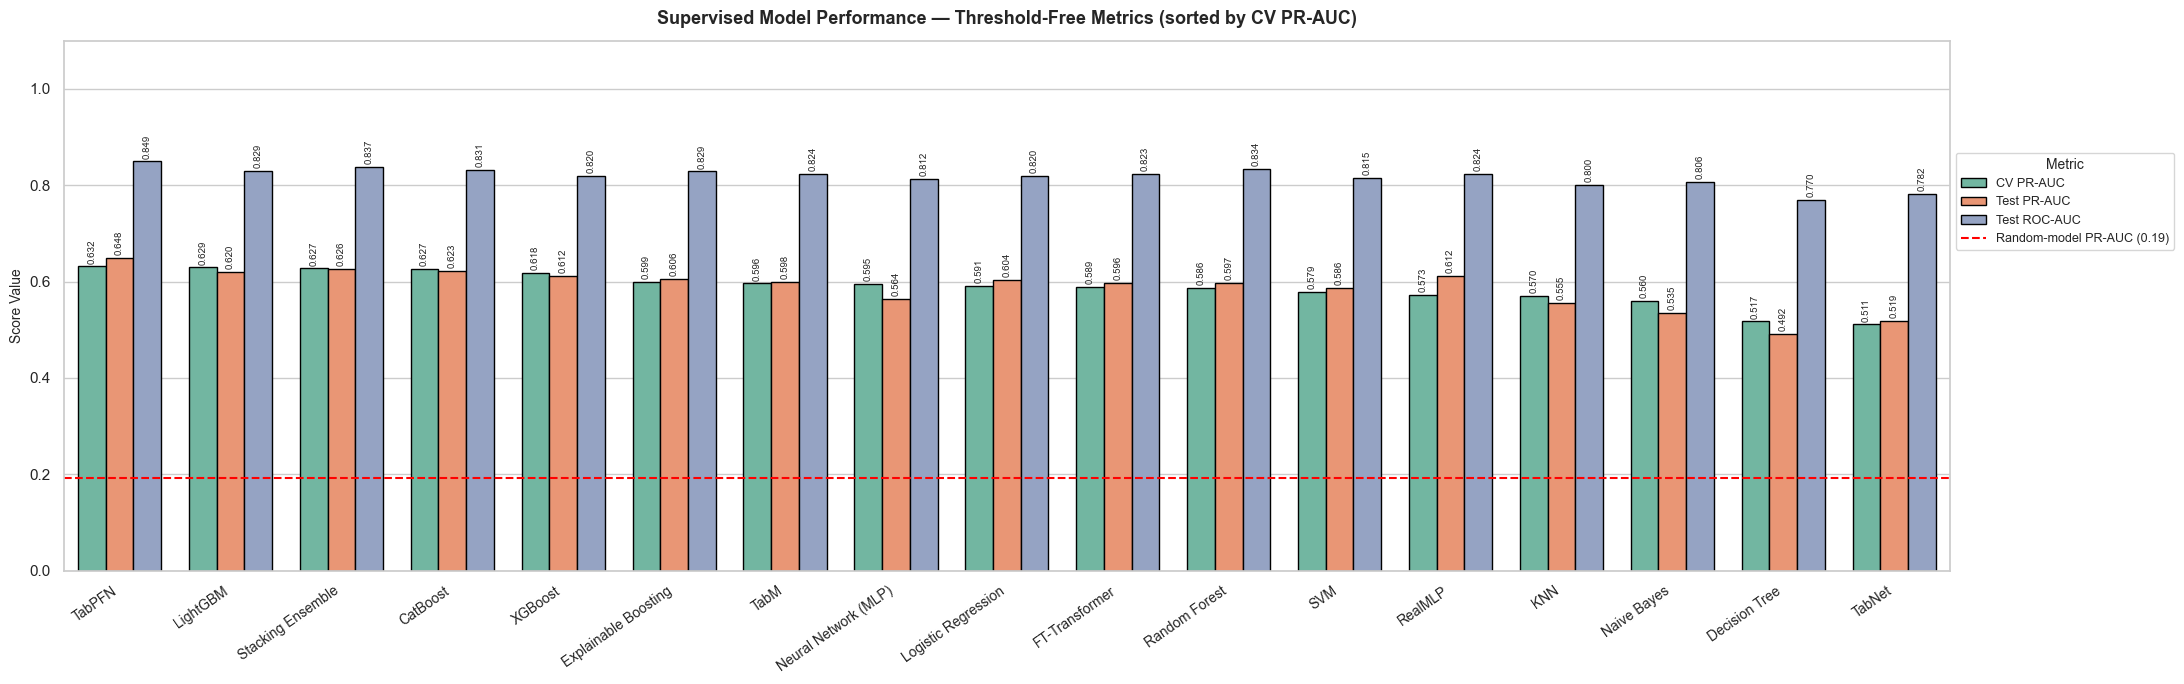

In [34]:
df_melted = df_comparison.reset_index()[['Model', 'CV PR-AUC', 'Test PR-AUC', 'Test ROC-AUC']].melt(
    id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(22, 7), dpi=100)
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2', edgecolor='black', width=0.75)
ax.axhline(y_test.mean(), color='red', linestyle='--', lw=1.5, label=f'Random-model PR-AUC ({y_test.mean():.2f})')

plt.title('Supervised Model Performance — Threshold-Free Metrics (sorted by CV PR-AUC)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('')
plt.ylabel('Score Value', fontsize=10)
plt.ylim(0, 1.1)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.legend(title='Metric', loc='upper left', bbox_to_anchor=(1, 0.8), fontsize=9, title_fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=7, rotation=90)

plt.tight_layout()
save_figure("model_comparison_barchart.png")
plt.show()

* **The top of the table is a statistical tie.** TabPFN has the best CV PR-AUC (0.632), but LightGBM (0.629), the Stacking Ensemble (0.627), CatBoost (0.627) and XGBoost (0.618) all lie within its standard error (± 0.018). On the test set the same group scores PR-AUC 0.61–0.65 and ROC-AUC 0.82–0.85.
* **Non-linear models help here, unlike in the lung module:** gradient-boosted trees and TabPFN beat logistic regression (0.591) by more than one standard error. Kidney risk depends on thresholds and interactions — BUN, for example, rises steeply only once kidney function is lost.
* **The deep tabular models did not beat boosted trees:** TabM (0.596), FT-Transformer (0.589), RealMLP (0.573) and TabNet (0.511) sit mid-table or below, a common result on small tables (4,378 training rows). TabPFN is the exception: it is pre-trained, so it doesn't need this data to learn a representation.
* **SMOTE:** cross-validation switched it *on* for the boosted trees and Naive Bayes, and *off* for every other model.
* All 17 models are well above the random baseline (PR-AUC 0.19).

### Confusion Matrix

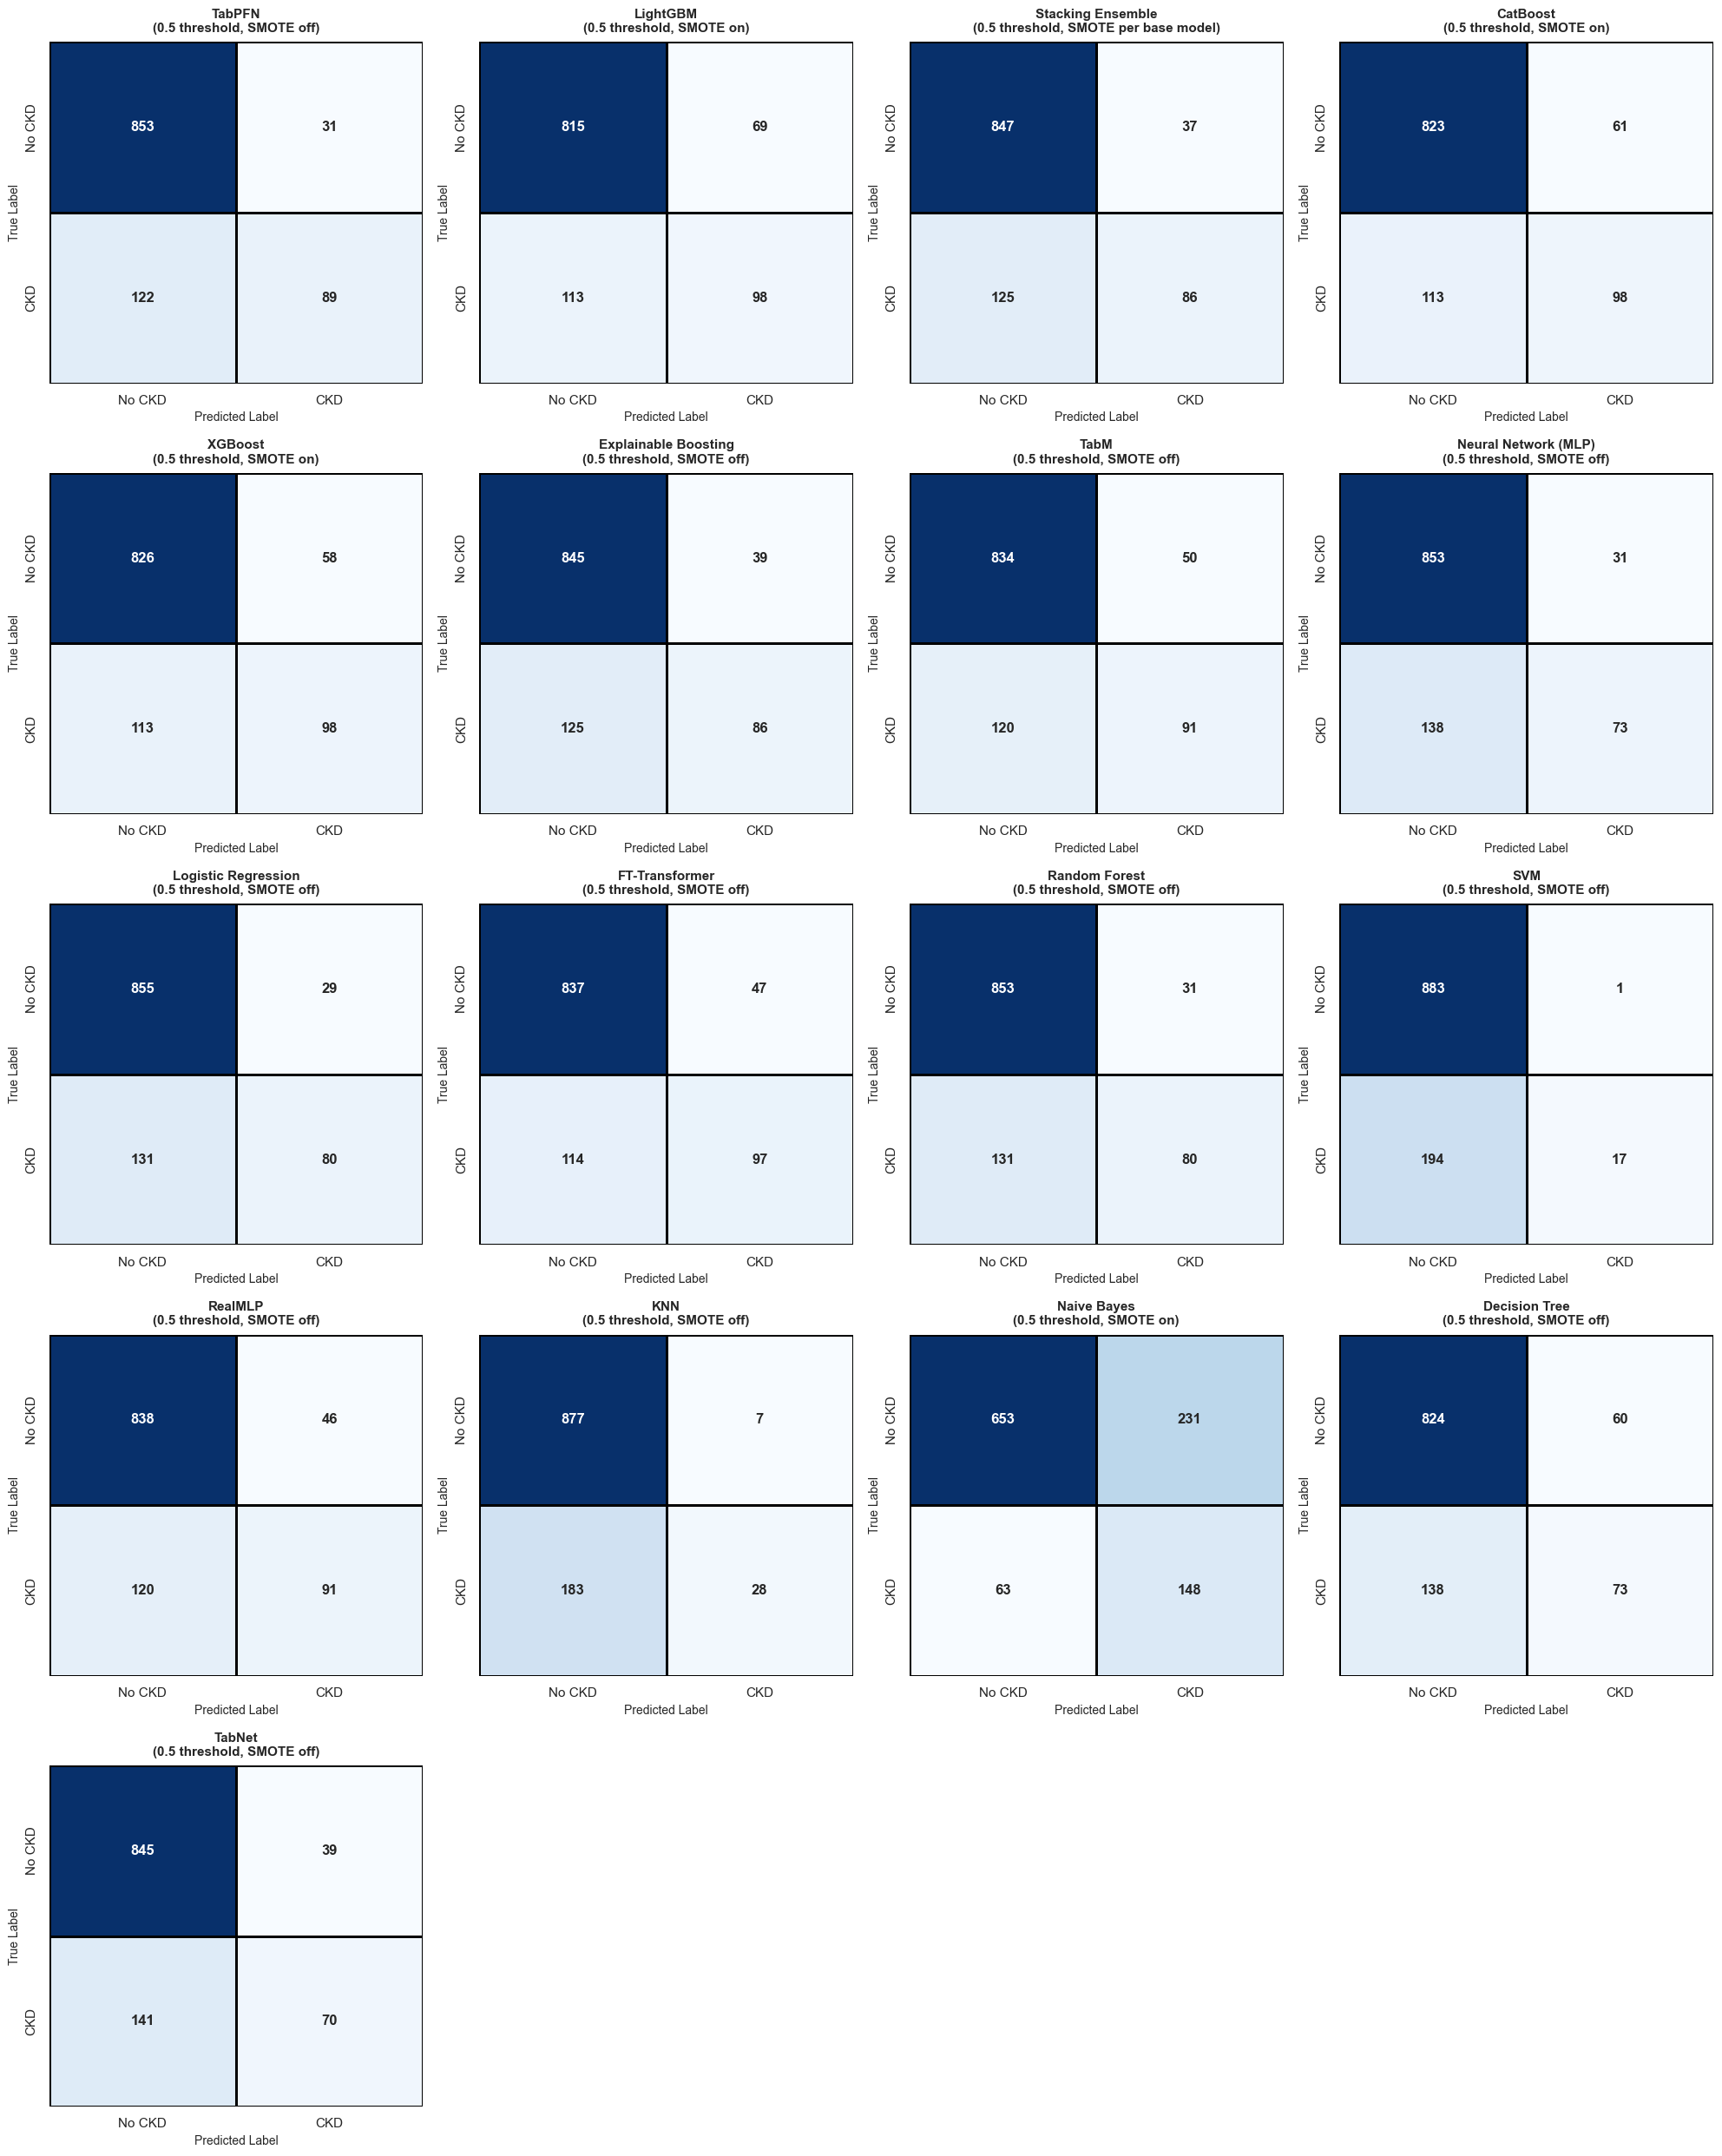

In [35]:
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

for i, name in enumerate(df_comparison.index):
    cm = confusion_matrix(y_test, fitted_models[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=1, linecolor='black', ax=axes[i])
    axes[i].set_title(f"{name}\n(0.5 threshold, SMOTE {cv_summary[name]['SMOTE']})", fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

for j in range(len(df_comparison), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
save_figure("models_confusion_matrix.png")
plt.show()

* At the default 0.5 threshold most models catch fewer than half of the CKD patients (recall 0.33–0.46): at 19 % prevalence, models trained without oversampling rarely output a probability above 0.5. SVM is the extreme case (precision 0.94, recall 0.08); Naive Bayes shows the opposite (recall 0.70, precision 0.39).
* These matrices compare *operating points*, not model quality. The threshold is chosen properly in the Threshold Analysis section.

### ROC, PR Curve

AUC (area under the curve) measures a model's ability to tell the classes apart: 0.5 is random guessing, 1.0 is perfect. For imbalanced data the PR curve is the more demanding view, because its baseline is the prevalence (0.19), not 0.5.

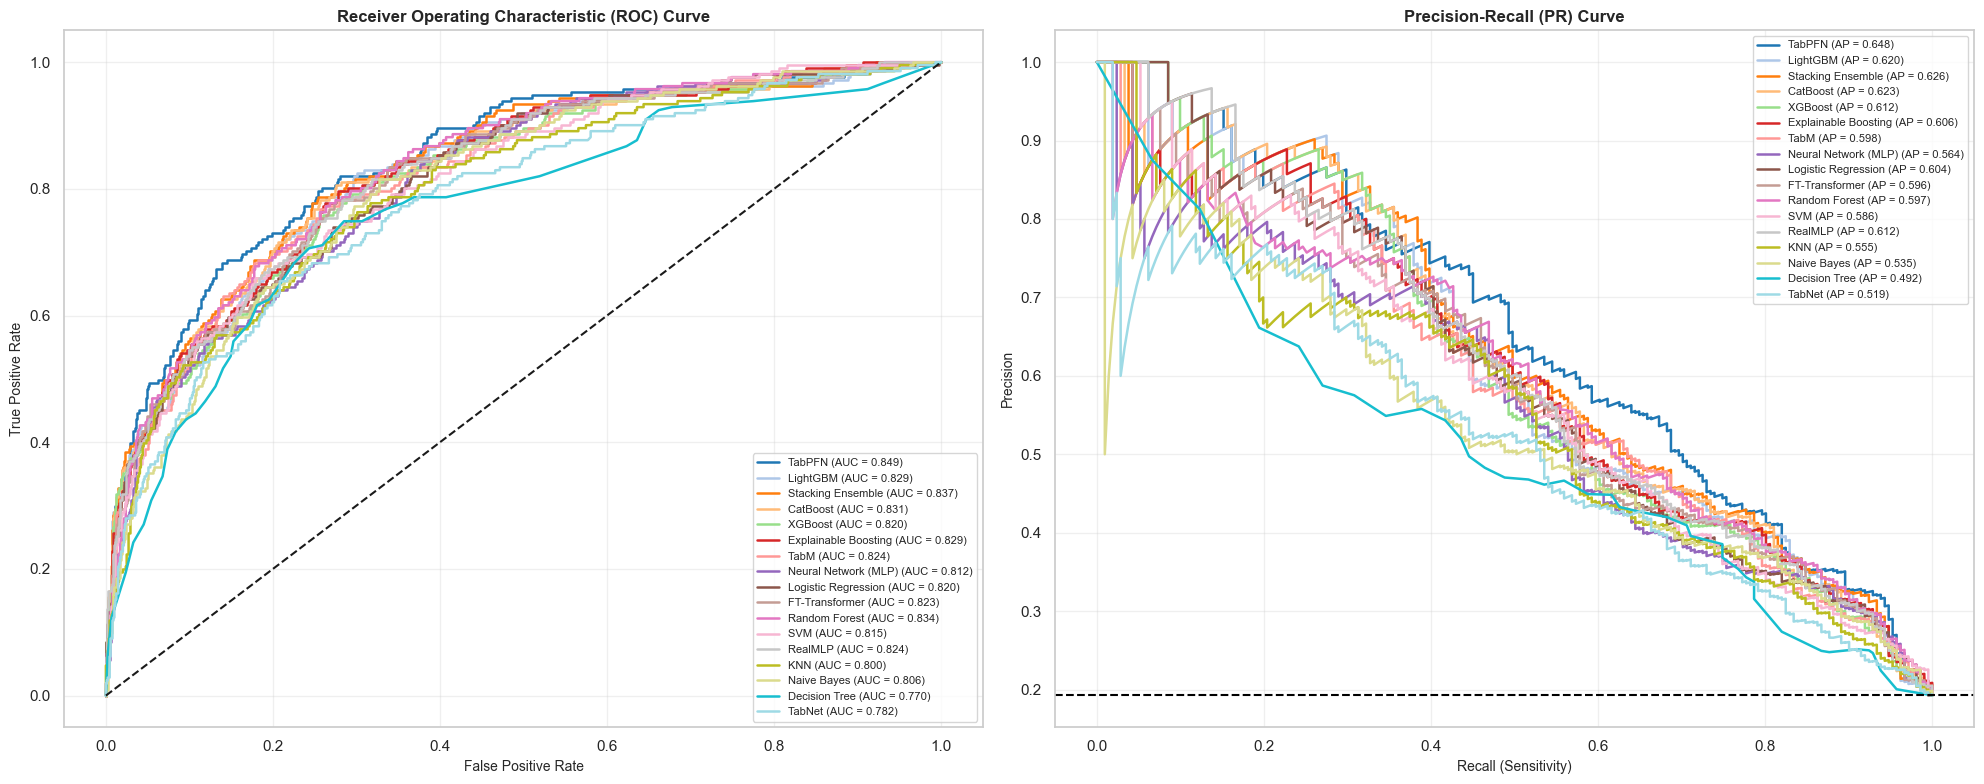

In [36]:
plt.figure(figsize=(20, 8), dpi=100)
ax_roc = plt.subplot(1, 2, 1)
ax_pr = plt.subplot(1, 2, 2)
colors = plt.cm.tab20(np.linspace(0, 1, len(df_comparison)))

for color, name in zip(colors, df_comparison.index):
    scores = test_scores[name]
    fpr, tpr, _ = roc_curve(y_test, scores)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, scores)
    ax_roc.plot(fpr, tpr, color=color, lw=1.8, label=f"{name} (AUC = {df_comparison.loc[name, 'Test ROC-AUC']:.3f})")
    ax_pr.plot(recall_vals, precision_vals, color=color, lw=1.8, label=f"{name} (AP = {df_comparison.loc[name, 'Test PR-AUC']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.legend(loc='lower right', fontsize=8)
ax_roc.grid(True, alpha=0.3)

ax_pr.axhline(y_test.mean(), color='black', linestyle='--', lw=1.5)
ax_pr.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall (Sensitivity)', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
save_figure("roc_pr_curve.png")
plt.show()

* The ROC curves are tightly bunched between AUC 0.80 and 0.85, with the decision tree (0.77) and TabNet (0.78) trailing: well-tuned models rank patients very similarly.
* The PR curves separate more. TabPFN's curve stays highest across most recall levels, and every model falls to a precision of about 0.3 by recall 0.8 — catching most CKD cases means flagging roughly two healthy people per true case.

# Best Supervised Model

**Selection rule — one standard error.** Picking the single highest score over-reads noise: the top models here differ by less than their own fold-to-fold variation. Following Breiman et al. (1984) and Hastie et al. (2009), we take the best CV PR-AUC, subtract one standard error, and choose the **simplest** model that clears that bar. "Simplest" means most interpretable and cheapest to deploy: glass-box models, then tree ensembles, then deep models, then foundation models and ensembles. Only training-set cross-validation is used, never the test set.

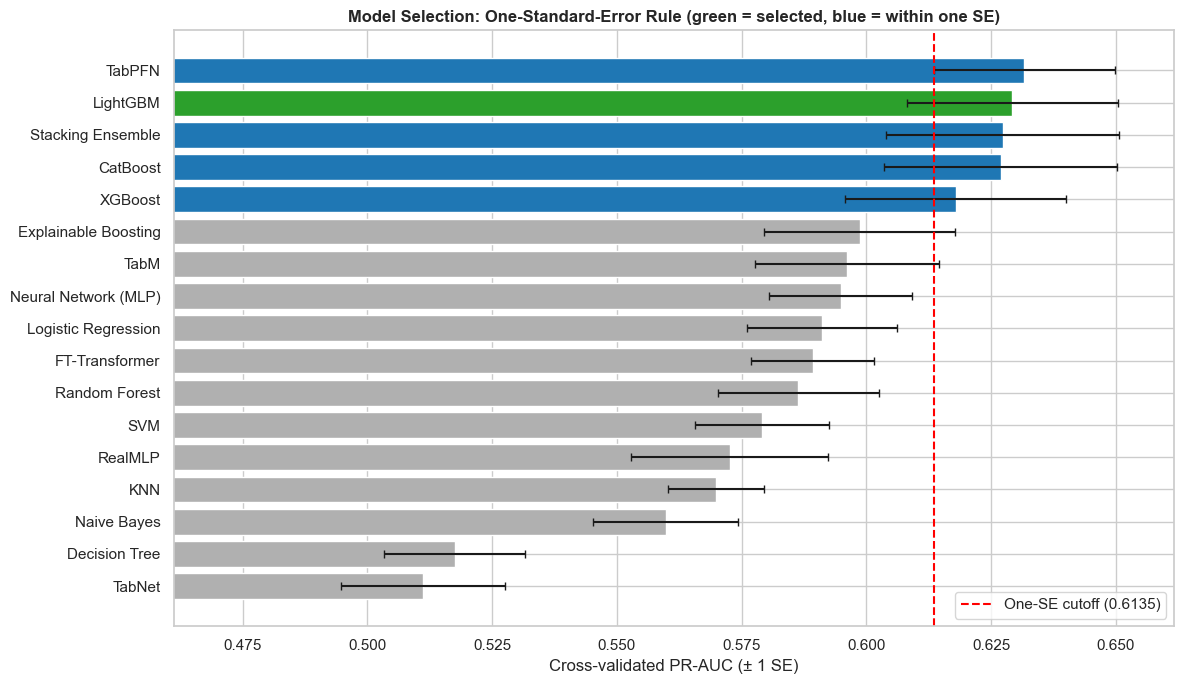

Highest CV PR-AUC     : TabPFN (0.6316 ± 0.0181 SE)
One-SE cutoff         : 0.6135
Models within one SE  : ['LightGBM', 'XGBoost', 'CatBoost', 'TabPFN', 'Stacking Ensemble']

🏆 The Best Model is: LightGBM
CV PR-AUC   : 0.6293 (Primary)
Test PR-AUC : 0.6199
Test ROC-AUC: 0.8294


In [37]:
# Simplest -> most complex (interpretability and deployment cost)
complexity_order = ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Explainable Boosting', 'KNN', 'SVM',
                    'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost', 'Neural Network (MLP)', 'TabNet',
                    'RealMLP', 'TabM', 'FT-Transformer', 'TabPFN', 'Stacking Ensemble']

top_model = df_comparison['CV PR-AUC'].idxmax()
top_score, top_se = df_comparison.loc[top_model, ['CV PR-AUC', 'CV SE']]
one_se_cutoff = top_score - top_se
within_one_se = [m for m in complexity_order
                 if m in df_comparison.index and df_comparison.loc[m, 'CV PR-AUC'] >= one_se_cutoff]
best_model_name = within_one_se[0]

plt.figure(figsize=(12, 7))
ranked = df_comparison.sort_values('CV PR-AUC')
bar_colors = ['#2ca02c' if m == best_model_name else ('#1f77b4' if m in within_one_se else '#b0b0b0') for m in ranked.index]
plt.barh(ranked.index, ranked['CV PR-AUC'], xerr=ranked['CV SE'], color=bar_colors, capsize=3)
plt.axvline(one_se_cutoff, color='red', linestyle='--', lw=1.5, label=f'One-SE cutoff ({one_se_cutoff:.4f})')
plt.xlim(ranked['CV PR-AUC'].min() - 0.05, top_score + 0.03)
plt.xlabel('Cross-validated PR-AUC (± 1 SE)')
plt.title('Model Selection: One-Standard-Error Rule (green = selected, blue = within one SE)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
save_figure("model_selection_one_se.png")
plt.show()

print(f"Highest CV PR-AUC     : {top_model} ({top_score:.4f} ± {top_se:.4f} SE)")
print(f"One-SE cutoff         : {one_se_cutoff:.4f}")
print(f"Models within one SE  : {within_one_se}")
print(f"\n🏆 The Best Model is: {best_model_name}")
print(f"CV PR-AUC   : {df_comparison.loc[best_model_name, 'CV PR-AUC']:.4f} (Primary)")
print(f"Test PR-AUC : {df_comparison.loc[best_model_name, 'Test PR-AUC']:.4f}")
print(f"Test ROC-AUC: {df_comparison.loc[best_model_name, 'Test ROC-AUC']:.4f}")

* TabPFN has the highest CV PR-AUC, but five models sit within one standard error of it. The one-SE rule picks the simplest of them: **LightGBM**, a CPU-only gradient-boosted tree (fast, small, exact TreeSHAP explanations) whose CV PR-AUC (0.629) is only 0.002 below TabPFN's.
* On the untouched test set LightGBM scores PR-AUC 0.620 and ROC-AUC 0.829, consistent with its cross-validated score, so there is no sign of overfitting to the CV folds.

### Model Calibration
The deployed model has to output probabilities we can say out loud ("a 30 % chance of CKD"), and the decision threshold must be set on *those* probabilities. So calibration comes before threshold analysis. `CalibratedClassifierCV` fits isotonic regression on held-out folds of the original, un-oversampled data, which also removes any probability inflation left by SMOTE.

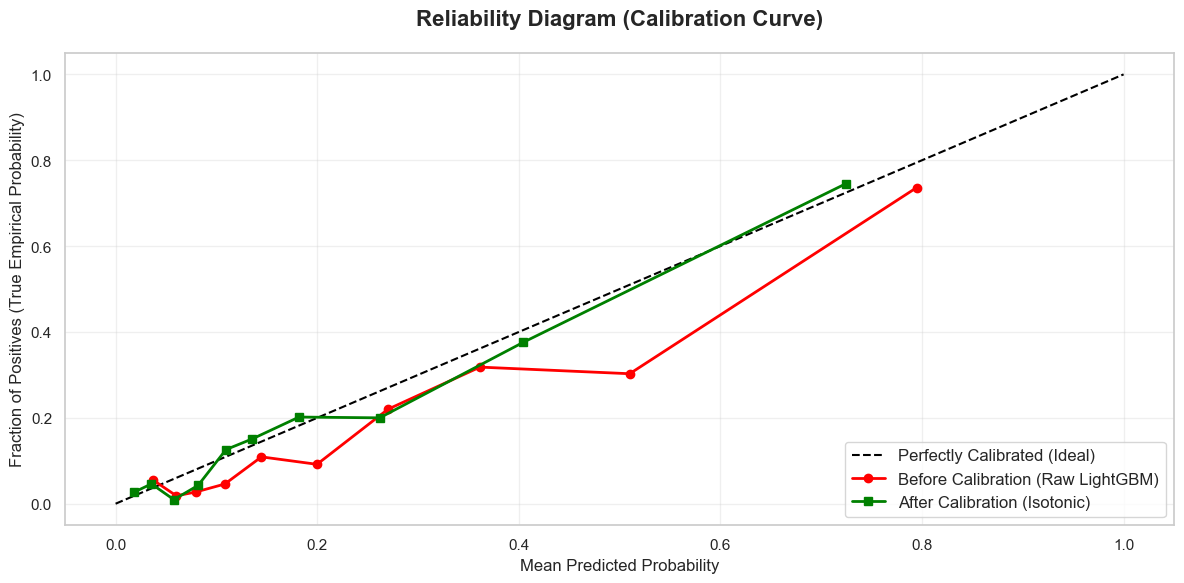

In [38]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Wrap the winning pipeline with a CalibratedClassifierCV
# cv=3 will cross-validate and retrain the model internally to avoid data leakage during calibration
winner_model = fitted_models[best_model_name]
calibrated_clf = CalibratedClassifierCV(estimator=winner_model, method='isotonic', cv=3)
calibrated_clf.fit(X_train, y_train)

raw_probas = positive_scores(winner_model, X_test)
calib_probas = calibrated_clf.predict_proba(X_test)[:, 1]
has_raw_probabilities = hasattr(winner_model, 'predict_proba')   # SVM only has a decision function

# We use strategy='quantile' since the dataset is imbalanced
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calib_probas, n_bins=10, strategy='quantile')

plt.figure(figsize=(12, 6), dpi=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated (Ideal)')
if has_raw_probabilities:
    prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_probas, n_bins=10, strategy='quantile')
    plt.plot(prob_pred_raw, prob_true_raw, marker='o', color='red', lw=2, label=f'Before Calibration (Raw {best_model_name})')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', color='green', lw=2, label='After Calibration (Isotonic)')

plt.title('Reliability Diagram (Calibration Curve)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (True Empirical Probability)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_figure("reliability_diagram.png")
plt.show()

### Threshold Analysis
The threshold is chosen on **out-of-fold predictions from the training set**: every training patient is scored by a calibrated model that never saw them. The original notebook tuned it on the test set, which made the reported test metrics optimistic.

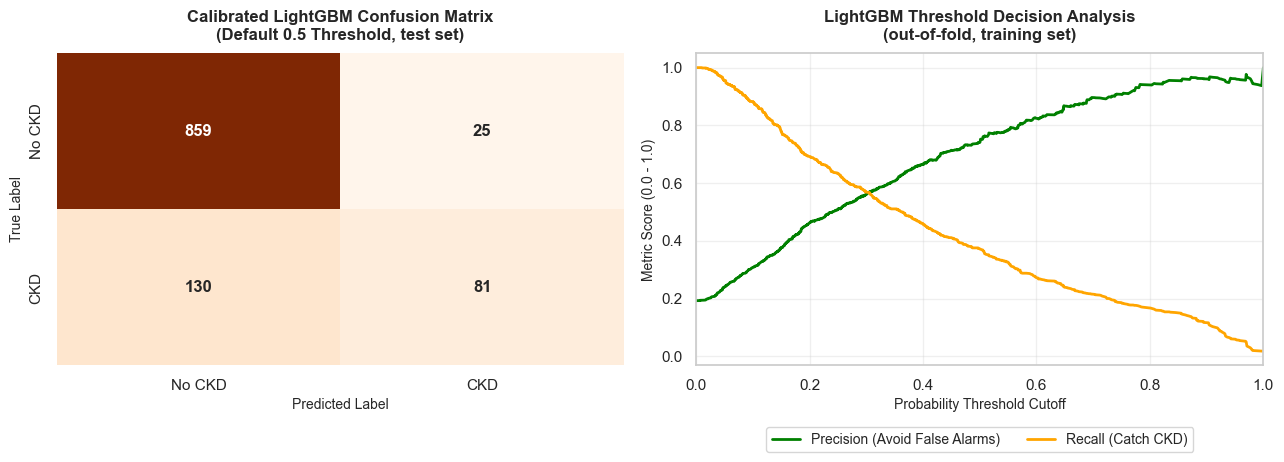


========================= OPERATIONAL CLINICAL IMPACT TABLE (test set) =========================


,Caught Disease (True Positives),Missed Disease (False Negatives),False Alarms (False Positives),Recall,Healthy Flagged Rate
Threshold,,,,,
0.05,201,10,636,95.3%,71.9%
0.10,197,14,451,93.4%,51.0%
0.15,170,41,281,80.6%,31.8%
0.20,152,59,202,72.0%,22.9%
0.30,128,83,109,60.7%,12.3%
0.50,81,130,25,38.4%,2.8%


In [39]:
oof_jobs = 1 if best_model_name in GPU_MODELS else 5
oof_probas = cross_val_predict(
    CalibratedClassifierCV(estimator=clone(winner_model), method='isotonic', cv=3),
    X_train, y_train, cv=cv_strategy, method='predict_proba', n_jobs=oof_jobs
)[:, 1]

plt.figure(figsize=(13, 5), dpi=100)

# Test-set confusion matrix at the default 0.5 threshold on calibrated probabilities
default_preds = np.where(calib_probas >= 0.5, 1, 0)
cm = confusion_matrix(y_test, default_preds)
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'Calibrated {best_model_name} Confusion Matrix\n(Default 0.5 Threshold, test set)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# THRESHOLD OVERLAY ANALYSIS (out-of-fold training predictions)
precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probas)
plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label='Precision (Avoid False Alarms)', color='green', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall (Catch CKD)', color='orange', lw=2)
plt.title(f'{best_model_name} Threshold Decision Analysis\n(out-of-fold, training set)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Probability Threshold Cutoff', fontsize=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=10)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

# SIMULATION TABLE (test set, calibrated probabilities)
simulation_data = []
for t in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    sim_preds = np.where(calib_probas >= t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, sim_preds).ravel()
    simulation_data.append({
        'Threshold': t,
        'Caught Disease (True Positives)': tp,
        'Missed Disease (False Negatives)': fn,
        'False Alarms (False Positives)': fp,
        'Recall': f"{tp / (tp + fn):.1%}",
        'Healthy Flagged Rate': f"{fp / (tn + fp):.1%}"
    })

df_sim = pd.DataFrame(simulation_data).set_index('Threshold')
print("\n========================= OPERATIONAL CLINICAL IMPACT TABLE (test set) =========================")
display(df_sim)

* The table shows the clinical trade-off directly: a 0.10 threshold catches 93 % of CKD patients but flags half of the healthy ones; a 0.30 threshold flags only 12 % of healthy patients but misses 39 % of CKD cases.
* The cost-optimal threshold computed next lies between these two.

### Automated Cost-Based Threshold Optimization

Instead of guessing, we compute the optimal threshold from a clinical cost function: a missed CKD case (False Negative) costs 5 and a false alarm (False Positive) costs 1. The cost is summed over **patient counts** (5·FN + 1·FP), which is the actual clinical cost. The original formula instead added the rates 5·(1 − recall) + (1 − precision). For perfectly calibrated probabilities, decision theory puts the optimum at *p* = 1 / (1 + 5) ≈ 0.167, a cross-check on the empirical result.

Automatically determined optimal threshold (out-of-fold, training set): 0.1750
Bayes-optimal threshold for perfectly calibrated probabilities:           0.1667

=== Metrics at Optimal Threshold (test set) ===
Recall (Sensitivity) : 0.7536
Precision            : 0.4025
F1-Score             : 0.5248
Specificity          : 0.7330


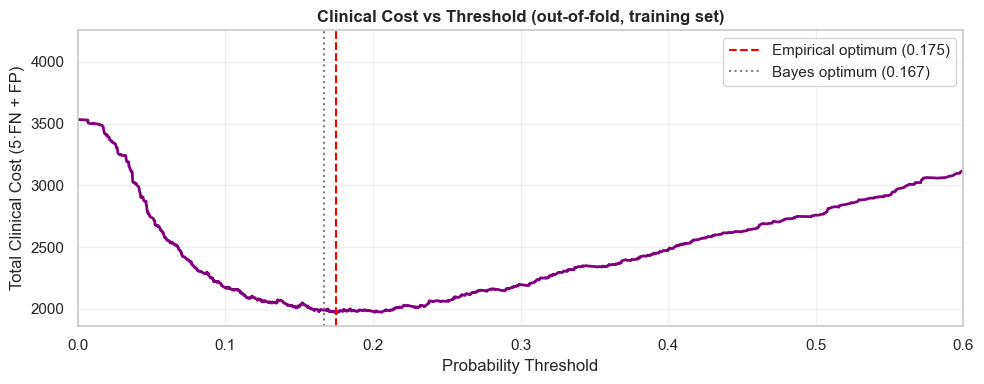

In [40]:
FN_COST, FP_COST = 5, 1

candidate_thresholds = np.unique(oof_probas)
positives = (y_train.values == 1)
total_cost = np.array([FN_COST * np.sum(positives & (oof_probas < t)) + FP_COST * np.sum(~positives & (oof_probas >= t))
                       for t in candidate_thresholds])

best_threshold = float(candidate_thresholds[np.argmin(total_cost)])
bayes_threshold = FP_COST / (FP_COST + FN_COST)

print(f"Automatically determined optimal threshold (out-of-fold, training set): {best_threshold:.4f}")
print(f"Bayes-optimal threshold for perfectly calibrated probabilities:           {bayes_threshold:.4f}\n")

# Apply the training-set threshold to the untouched test set
sim_preds_best = np.where(calib_probas >= best_threshold, 1, 0)

print("=== Metrics at Optimal Threshold (test set) ===")
print(f"Recall (Sensitivity) : {recall_score(y_test, sim_preds_best):.4f}")
print(f"Precision            : {precision_score(y_test, sim_preds_best):.4f}")
print(f"F1-Score             : {f1_score(y_test, sim_preds_best):.4f}")
tn, fp, fn, tp = confusion_matrix(y_test, sim_preds_best).ravel()
print(f"Specificity          : {tn / (tn + fp):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(candidate_thresholds, total_cost, color='purple', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Empirical optimum ({best_threshold:.3f})')
plt.axvline(bayes_threshold, color='gray', linestyle=':', label=f'Bayes optimum ({bayes_threshold:.3f})')
plt.xlim(0, 0.6)
plt.xlabel('Probability Threshold')
plt.ylabel('Total Clinical Cost (5·FN + FP)')
plt.title('Clinical Cost vs Threshold (out-of-fold, training set)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Best Threshold In Confusion Matrix

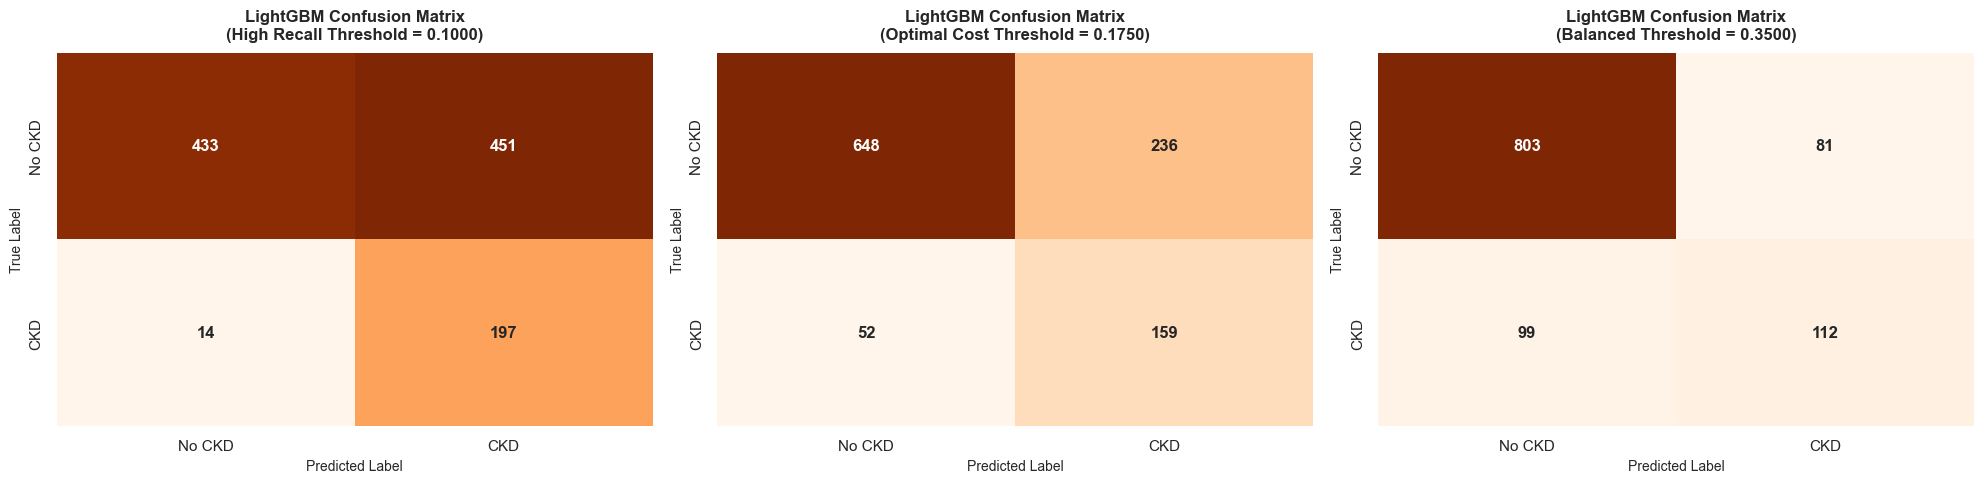

In [41]:
# Visualize Confusion Matrices for the top selected operational thresholds
plt.figure(figsize=(20, 5), dpi=100)
operating_points = [(0.10, 'High Recall Threshold'), (best_threshold, 'Optimal Cost Threshold'), (0.35, 'Balanced Threshold')]

for i, (t, label) in enumerate(operating_points, start=1):
    cm_t = confusion_matrix(y_test, np.where(calib_probas >= t, 1, 0))
    plt.subplot(1, 3, i)
    sns.heatmap(cm_t, annot=True, fmt='d', cmap='Oranges', cbar=False,
                xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
                annot_kws={'size': 12, 'weight': 'bold'})
    plt.title(f'{best_model_name} Confusion Matrix\n({label} = {t:.4f})', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Predicted Label', fontsize=10)
    plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
save_figure("optimal_threshold_confusion_matrix.png")
plt.show()

In [42]:
def operating_metrics(label, probas, threshold):
    preds = np.where(probas >= threshold, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    return {'Model': label, 'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall': recall_score(y_test, preds, zero_division=0),
            'F1-Score': f1_score(y_test, preds, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, probas), 'PR-AUC (AP)': average_precision_score(y_test, probas),
            'Missed Patients (FN)': int(fn), 'False Alarms (FP)': int(fp)}

calibration_rows = [operating_metrics(f'Calibrated {best_model_name} @ 0.5', calib_probas, 0.5),
                    operating_metrics(f'Calibrated {best_model_name} @ {best_threshold:.3f} (optimal)', calib_probas, best_threshold)]
if has_raw_probabilities:
    calibration_rows.insert(0, operating_metrics(f'Raw {best_model_name} @ 0.5', raw_probas, 0.5))
df_calib_comp = pd.DataFrame(calibration_rows).set_index('Model')

print("================================ CALIBRATION PERFORMANCE COMPARISON ================================")
display(df_calib_comp.style.background_gradient(
    cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds', subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Patients (FN)': '{:,.0f}', 'False Alarms (FP)': '{:,.0f}'
}))

================================ CALIBRATION PERFORMANCE COMPARISON ================================


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP),Missed Patients (FN),False Alarms (FP)
Model,,,,,,,,
Raw LightGBM @ 0.5,0.8338,0.5868,0.4645,0.5185,0.8294,0.6199,113,69
Calibrated LightGBM @ 0.5,0.8584,0.7642,0.3839,0.5110,0.8340,0.6240,130,25
Calibrated LightGBM @ 0.175 (optimal),0.7370,0.4025,0.7536,0.5248,0.8340,0.6240,52,236


* **Calibration removes SMOTE's inflation.** The raw LightGBM, trained on oversampled data, over-predicts: its mean probability is 0.26 against a true rate of 0.19, and in the reliability diagram it sits below the diagonal above ~0.3. Isotonic calibration brings the mean to 0.20 and keeps the curve on the diagonal. The ranking barely moves (ROC-AUC 0.829 → 0.834).
* **The threshold matters more than the model.** At 0.5 the calibrated model catches only 38 % of CKD patients (130 missed). At the cost-optimal 0.175 it catches 75 % (52 missed), at the price of 236 false alarms — for kidney screening, a false alarm costs one blood test and one urine test.
* The empirical optimum (0.175) sits right next to the Bayes-optimal 1/6 ≈ 0.167, which is what well-calibrated probabilities should give.

### Bootstrapped Confidence Intervals (Model Reliability)

In medical literature, point estimates (like Recall = 0.90) are rarely reported alone. Because the test set is one sample of the population, we need to know how much each metric would move on another sample of patients.

Bootstrapping (resampling the test set with replacement) simulates 1,000 test sets and evaluates the calibrated model at the optimal threshold on each. The 2.5th–97.5th percentiles give the 95 % confidence interval for each metric.

In [43]:
from sklearn.utils import resample

n_iterations = 1000
n_size = len(X_test)
y_test_array = y_test.values
test_preds = sim_preds_best

bootstrapped = {'Recall': [], 'Precision': [], 'ROC-AUC': [], 'PR-AUC': []}

for i in range(n_iterations):
    # Resample the indices with replacement
    indices = resample(np.arange(n_size), replace=True, n_samples=n_size, random_state=i)
    y_true_boot, y_pred_boot, y_proba_boot = y_test_array[indices], test_preds[indices], calib_probas[indices]

    # Ensure the bootstrap sample contains both classes to calculate AUCs safely
    if len(np.unique(y_true_boot)) < 2:
        continue

    bootstrapped['Recall'].append(recall_score(y_true_boot, y_pred_boot, zero_division=0))
    bootstrapped['Precision'].append(precision_score(y_true_boot, y_pred_boot, zero_division=0))
    bootstrapped['ROC-AUC'].append(roc_auc_score(y_true_boot, y_proba_boot))
    bootstrapped['PR-AUC'].append(average_precision_score(y_true_boot, y_proba_boot))

# Helper function to calculate mean and 95% CI
def calc_ci(metrics_list, alpha=0.95):
    lower_bound = np.percentile(metrics_list, (1 - alpha) / 2 * 100)
    upper_bound = np.percentile(metrics_list, (1 + alpha) / 2 * 100)
    return np.mean(metrics_list), lower_bound, upper_bound

confidence_intervals = {}
print(f"=== 95% Bootstrapped Confidence Intervals ({n_iterations} Iterations, threshold {best_threshold:.3f}) ===")
for metric, values in bootstrapped.items():
    mean_val, lower_val, upper_val = calc_ci(values)
    confidence_intervals[metric] = {'mean': mean_val, 'ci_lower': lower_val, 'ci_upper': upper_val}
    print(f"{metric:9s} : {mean_val:.3f} (95% CI: {lower_val:.3f} - {upper_val:.3f})")

=== 95% Bootstrapped Confidence Intervals (1000 Iterations, threshold 0.175) ===
Recall    : 0.754 (95% CI: 0.698 - 0.810)
Precision : 0.401 (95% CI: 0.353 - 0.448)
ROC-AUC   : 0.834 (95% CI: 0.802 - 0.863)
PR-AUC    : 0.625 (95% CI: 0.559 - 0.687)


* **Recall 0.754 (95 % CI 0.698–0.810):** even in the pessimistic case the screen catches about 7 in 10 CKD patients.
* **ROC-AUC 0.834 (0.802–0.863) and PR-AUC 0.625 (0.559–0.687):** the intervals are wide because the test set holds only 211 CKD cases; more NHANES cycles would tighten them.
* These are honest estimates: the threshold was chosen on training data, so the test set played no part in any decision.

### Brier Score

The Brier score is the mean squared difference between the predicted probability and the actual outcome (0 or 1). Lower is better: it measures calibration and sharpness together. At 19 % prevalence, always predicting the prevalence scores ≈ 0.156, which is the bar to beat.

In [44]:
from sklearn.metrics import brier_score_loss

brier_reference = brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))
brier_calibrated = brier_score_loss(y_test, calib_probas)
print(f"Brier Score (Always predict prevalence): {brier_reference:.4f}")
if has_raw_probabilities:
    brier_raw = brier_score_loss(y_test, raw_probas)
    print(f"Brier Score (Raw {best_model_name}): {brier_raw:.4f}")
print(f"Brier Score (Calibrated {best_model_name}): {brier_calibrated:.4f}")

if has_raw_probabilities and brier_calibrated < brier_raw:
    print("\nInterpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).")
elif has_raw_probabilities and brier_calibrated > brier_raw:
    print("\nInterpretation: The raw model has a lower Brier Score; its probabilities were already well calibrated, and isotonic regression mainly adds a little variance.")

Brier Score (Always predict prevalence): 0.1556
Brier Score (Raw LightGBM): 0.1163
Brier Score (Calibrated LightGBM): 0.1095

Interpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).


# Feature Importance

### Shap

To understand what drives the predictions we use SHAP (SHapley Additive exPlanations). The explainer matches the model type: exact `TreeExplainer` for tree ensembles, `LinearExplainer` for logistic regression, and a model-agnostic permutation explainer otherwise. The original cell assumed a tree model and would fail on any other winner. Values are on the base model's margin (log-odds) scale; isotonic calibration is a monotone re-mapping, so it doesn't change which features push a patient up or down.

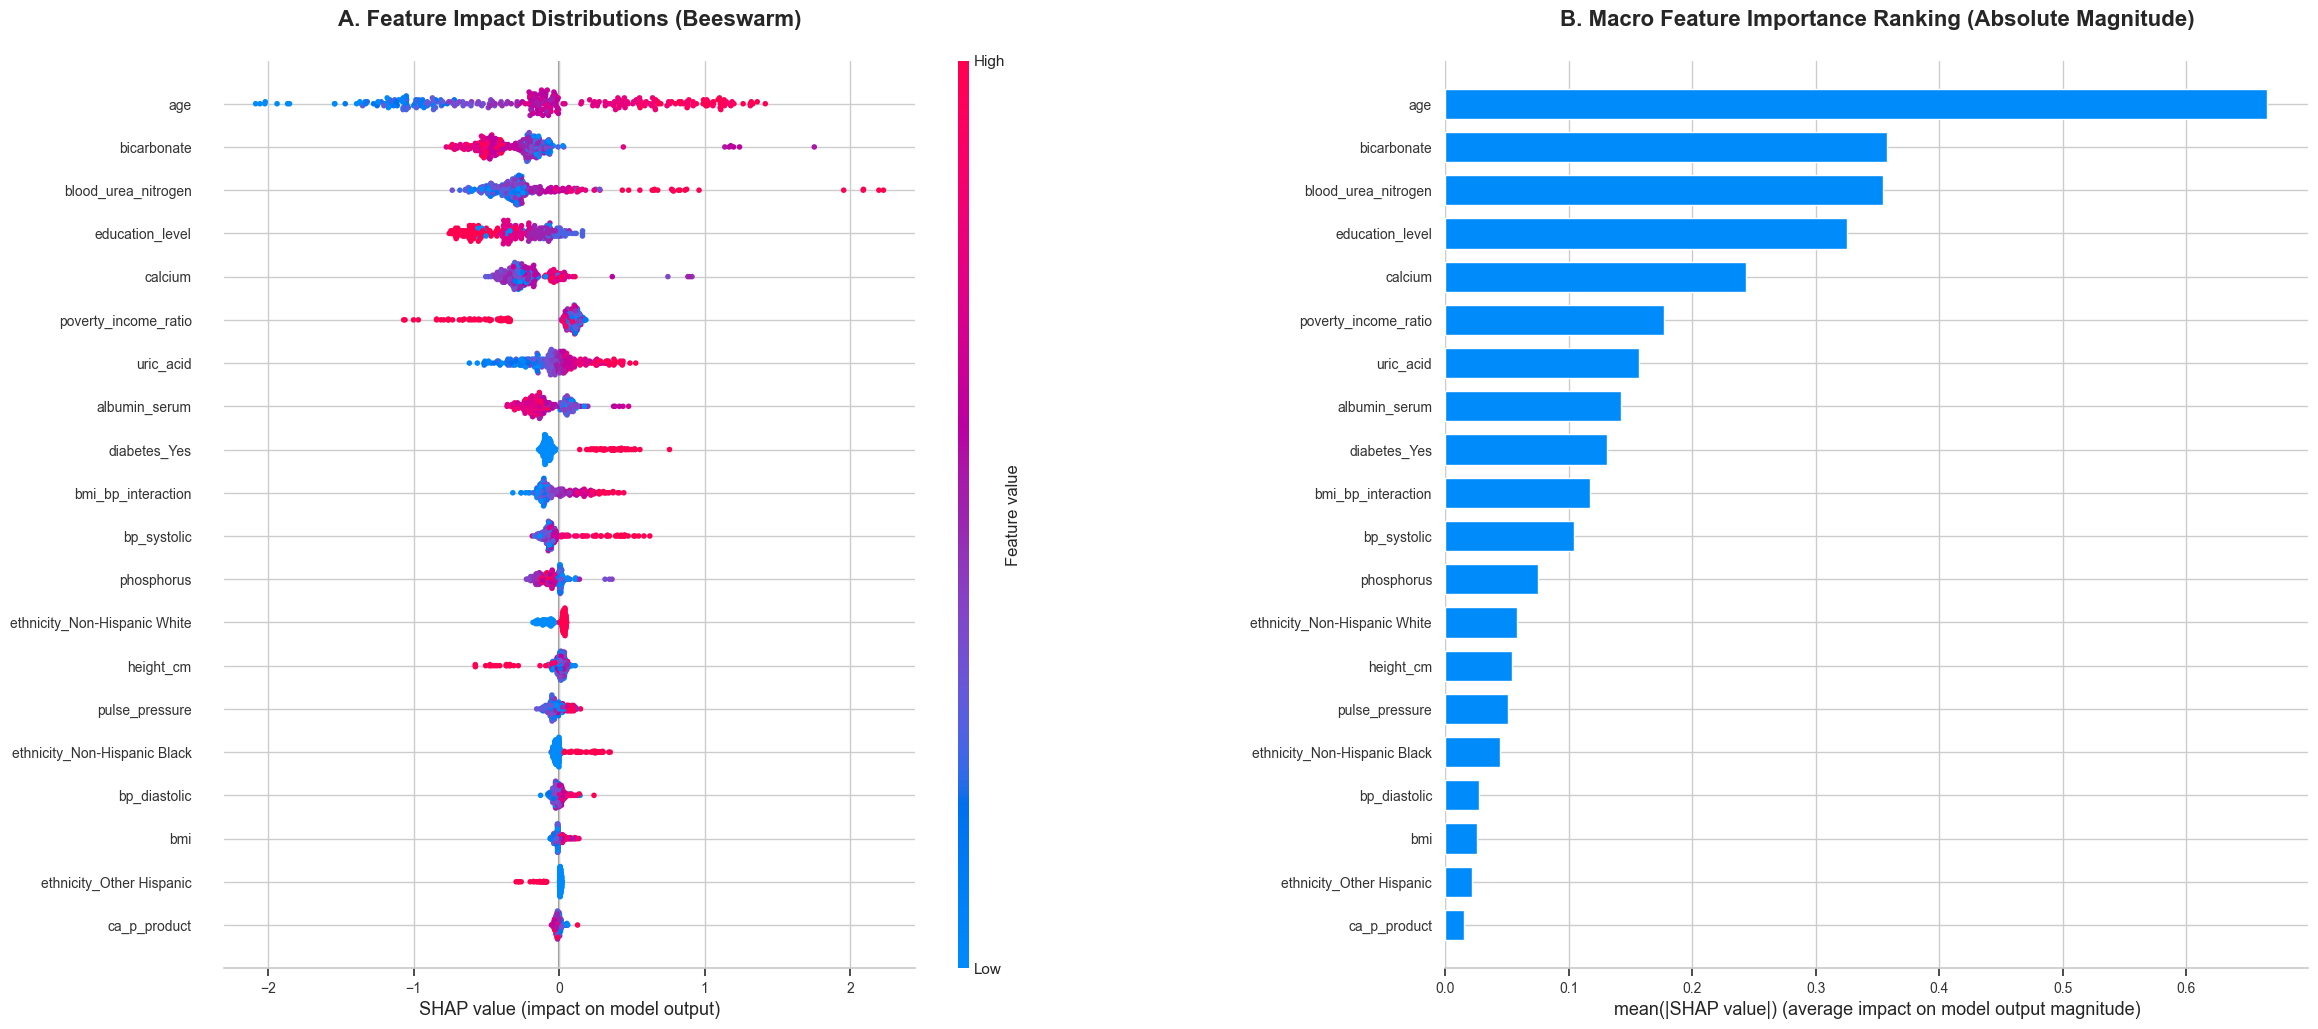

In [45]:
import shap
import matplotlib.gridspec as gridspec

# Stacking has no single classifier step; in that case explain the best single pipeline
pipeline_models = [m for m in df_comparison.index if hasattr(fitted_models[m], 'named_steps')]
explain_name = best_model_name if best_model_name in pipeline_models else pipeline_models[0]
if explain_name != best_model_name:
    print(f"{best_model_name} has no single classifier step; SHAP explains {explain_name} instead.")

# Extract the best pipeline and its components
best_pipeline = fitted_models[explain_name]
model_object = best_pipeline.named_steps['classifier']
preprocessor = best_pipeline[:-1]           # engineering -> imputation -> (SMOTENC skipped at transform) -> encoding

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = list(best_pipeline.named_steps['encoding'].get_feature_names_out())

tree_models = (XGBClassifier, LGBMClassifier, CatBoostClassifier, RandomForestClassifier, DecisionTreeClassifier)
fast_explainer = isinstance(model_object, tree_models + (LogisticRegression,))
slow_model = explain_name in GPU_MODELS

def build_shap_explainer(model, background):
    if isinstance(model, tree_models):
        return shap.TreeExplainer(model)
    if isinstance(model, LogisticRegression):
        return shap.LinearExplainer(model, background)
    # Model-agnostic permutation explainer; a small background keeps slow (GPU) models tractable
    masker = shap.maskers.Independent(background, max_samples=25 if slow_model else 50)
    return shap.explainers.Permutation(lambda data: positive_scores(model, data), masker, feature_names=feature_names)

def compute_shap(explainer, data):
    if isinstance(explainer, shap.explainers.Permutation):
        # One forward + one backward pass over the features: the minimum the explainer accepts
        values = explainer(data, max_evals=2 * data.shape[1] + 1, silent=True)
    else:
        values = explainer(data)
    if len(values.values.shape) == 3:          # (samples, features, classes) -> positive class
        values = values[..., 1]
    return values

background = shap.sample(X_train_processed, 200, random_state=RANDOM_STATE)
explainer = build_shap_explainer(model_object, background)

# Extract a sample array for SHAP (the model-agnostic explainer is far slower, so it gets fewer rows)
n_explain = 300 if fast_explainer else (50 if slow_model else 150)
X_sample = X_test_processed[:n_explain]
shap_values = compute_shap(explainer, X_sample)
shap_values.feature_names = feature_names

fig = plt.figure(figsize=(24, 10), dpi=100)
gs = gridspec.GridSpec(1, 21)
ax1 = plt.subplot(gs[0, 0:9])
ax2 = plt.subplot(gs[0, 12:21])

# --- LEFT PLOT: Feature Impact Distributions (Beeswarm) ---
plt.sca(ax1)
shap.summary_plot(shap_values.values, X_sample, feature_names=feature_names, max_display=20, show=False, plot_size=None)
ax1.set_title('A. Feature Impact Distributions (Beeswarm)', fontsize=16, fontweight='bold', pad=25)
ax1.tick_params(axis='both', labelsize=10)

# --- RIGHT PLOT: Average Absolute SHAP Value (Global Bar) ---
plt.sca(ax2)
shap.summary_plot(shap_values.values, X_sample, plot_type="bar", feature_names=feature_names, max_display=20, show=False, plot_size=None)
ax2.set_title('B. Macro Feature Importance Ranking (Absolute Magnitude)', fontsize=16, fontweight='bold', pad=25)
ax2.tick_params(axis='both', labelsize=10)

save_figure("shap_analysis_macro_feature_importance.png")
plt.show()

1. **Age** dominates: older patients (red, right) are pushed strongly toward CKD, younger ones away from it.
2. **Bicarbonate** and **blood urea nitrogen** come next. High BUN — a waste product the kidneys clear — raises risk. Higher bicarbonate lowers it: low bicarbonate (metabolic acidosis) is a classic CKD complication.
3. **Socioeconomic factors** — higher education and a higher income ratio lower the predicted risk, reflecting access to care and better control of diabetes and hypertension.
4. **Calcium, uric acid, serum albumin, diabetes and systolic blood pressure** follow. Diabetes and high blood pressure are the two main causes of CKD, and low albumin accompanies protein loss in the urine.

The model relies on clinically sensible markers — none of them the label-defining eGFR or ACR.

### Permutation Importance

Global, model-agnostic importance. The **raw input columns** are shuffled one at a time and pushed through the full calibrated pipeline, so shuffling `bp_systolic` also scrambles the pulse pressure, MAP and BMI × BP built from it. The score drop is measured in PR-AUC.

--- Permutation Importance (drop in test PR-AUC when the column is shuffled) ---


,Feature,Importance_Mean,Importance_Std
0,age,0.114105,0.018280
9,blood_urea_nitrogen,0.111866,0.022315
14,uric_acid,0.040563,0.009502
7,bp_systolic,0.037981,0.005638
12,bicarbonate,0.034843,0.004363
17,diabetes,0.021946,0.004016
13,calcium,0.019274,0.005507
4,poverty_income_ratio,0.010324,0.008388
10,albumin_serum,0.008227,0.004148
6,height_cm,0.008126,0.002994


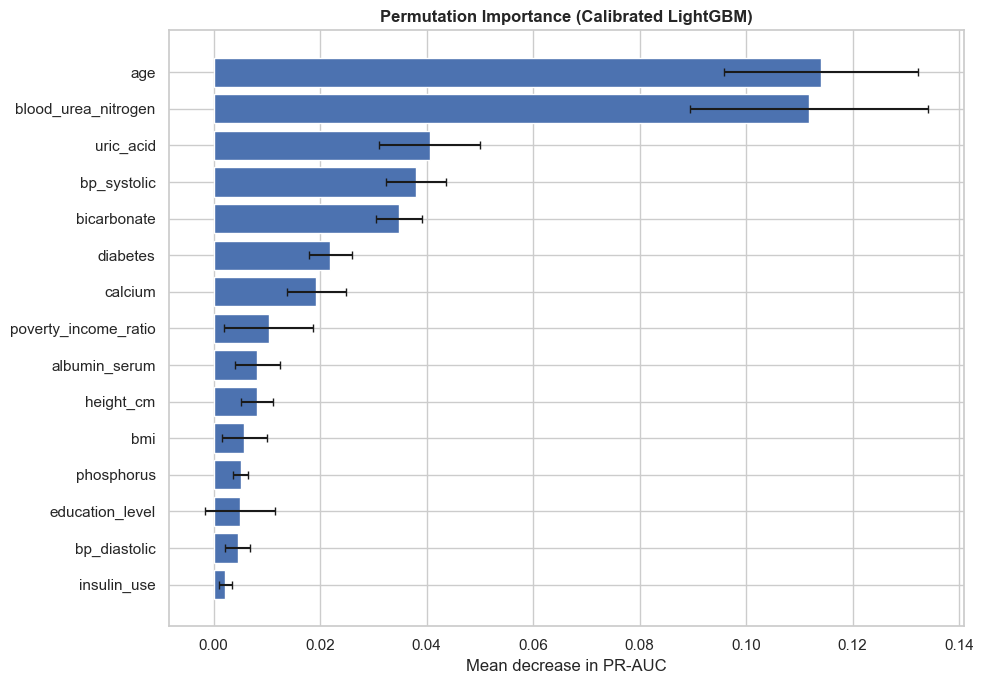

In [46]:
from sklearn.inspection import permutation_importance

perm_repeats = 3 if best_model_name in GPU_MODELS else 10
perm_jobs = 1 if best_model_name in GPU_MODELS else N_JOBS
result = permutation_importance(
    calibrated_clf, X_test, y_test, scoring='average_precision',
    n_repeats=perm_repeats, random_state=RANDOM_STATE, n_jobs=perm_jobs
)

# Format the results into a clean DataFrame
df_perm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)
df_perm_importance.to_csv(os.path.join(results_dir, 'permutational_feature_importance.csv'), index=False)

print("--- Permutation Importance (drop in test PR-AUC when the column is shuffled) ---")
display(df_perm_importance.head(10))

plt.figure(figsize=(10, 7))
top_perm = df_perm_importance.head(15).iloc[::-1]
plt.barh(top_perm['Feature'], top_perm['Importance_Mean'], xerr=top_perm['Importance_Std'], color='#4c72b0', capsize=3)
plt.xlabel('Mean decrease in PR-AUC')
plt.title(f'Permutation Importance (Calibrated {best_model_name})', fontweight='bold')
plt.tight_layout()
save_figure("permutation_importance.png")
plt.show()

* **Age (0.114)** and **blood urea nitrogen (0.112)** are by far the most important inputs: shuffling either costs the model more than 0.11 PR-AUC.
* Uric acid, systolic blood pressure, bicarbonate and diabetes status follow (0.02–0.04 each). Systolic blood pressure ranks higher here than in SHAP because here the raw column is shuffled, which also scrambles the three engineered features built from it.
* SHAP and permutation importance agree on the leading markers, so the ranking is robust.

# Unsupervised Learning

### Dimensionality Reduction (PCA & t-SNE)

First, we prepare the data and reduce its dimensions to see whether patients group naturally before any clustering. We use the numeric features after feature engineering, **scaled before KNN imputation** (the same order as the supervised pipeline).

In [47]:
X_unsup = add_custom_features(kidney_data)[numerical_features]
scaler_unsup = StandardScaler()
imputer_unsup = KNNImputer(n_neighbors=5)
X_unsup_scaled = imputer_unsup.fit_transform(scaler_unsup.fit_transform(X_unsup))
labels_all = kidney_data['ckd_present'].map({0: 'No CKD', 1: 'CKD Present'}).values

# Stratified sample for the O(n^2) methods and for readable scatter plots
sample_size = min(6000, int(0.8 * len(X_unsup_scaled)))
sample_idx, _ = train_test_split(np.arange(len(X_unsup_scaled)), train_size=sample_size,
                                 stratify=kidney_data['ckd_present'], random_state=RANDOM_STATE)
X_sample_unsup = X_unsup_scaled[sample_idx]
print(f"Unsupervised matrix: {X_unsup_scaled.shape} | sample for O(n^2) methods: {X_sample_unsup.shape}")

Unsupervised matrix: (5473, 17) | sample for O(n^2) methods: (4378, 17)


* **PCA (Principal Component Analysis):** Reduces the clinical features (age, blood pressure, metabolic panel…) to two principal components, to show the global variance and overall structure of the patient dataset on a 2D scatter plot.

* **t-SNE (T-distributed Stochastic Neighbor Embedding):** Unlike PCA, which captures global patterns, t-SNE preserves complex, non-linear, local relationships. It shows whether patients with similar clinical profiles form distinct "neighborhoods" (for example, sick vs. healthy).

Variance explained by PC1 + PC2: 35.3%


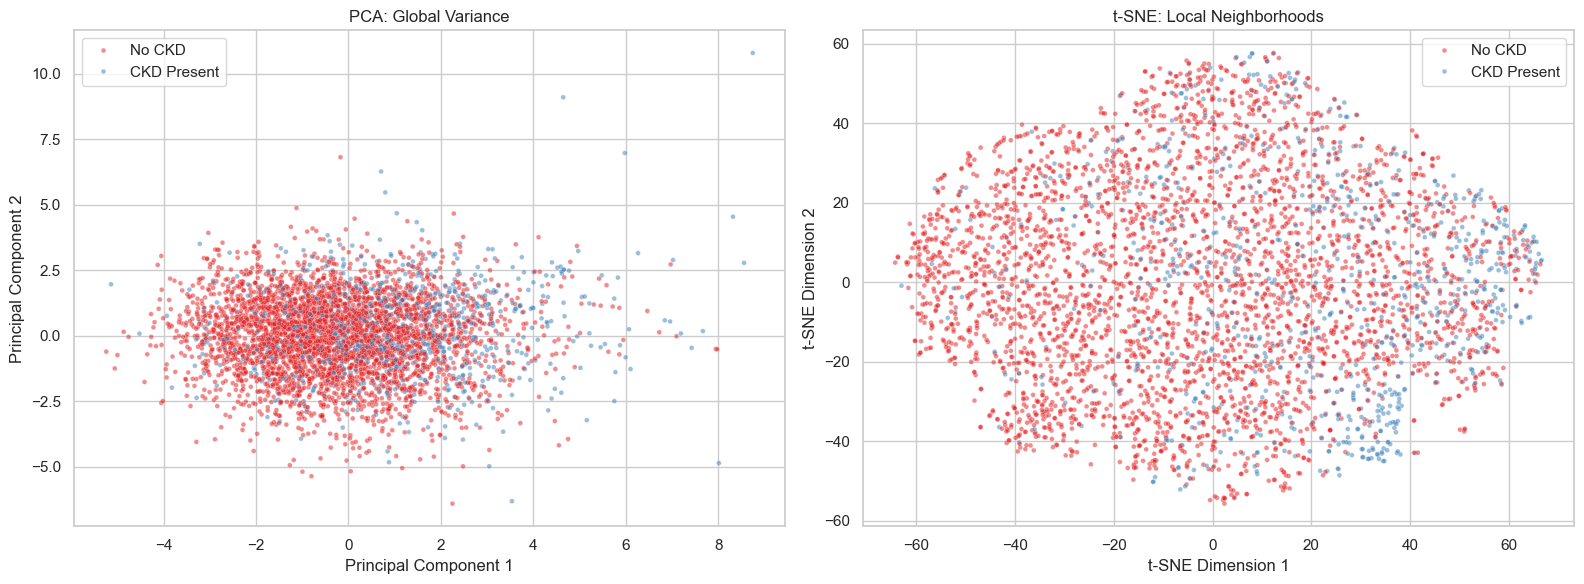

In [48]:
# PCA (Principal Component Analysis) — fitted on everyone, plotted on the sample
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_all = pca.fit_transform(X_unsup_scaled)
pca_result = pca_all[sample_idx]
print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum():.1%}")

# t-SNE (T-distributed Stochastic Neighbor Embedding)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X_sample_unsup)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
labels = labels_all[sample_idx]

sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels, palette='Set1', ax=ax[0], alpha=0.5, s=12)
ax[0].set_title('PCA: Global Variance')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=labels, palette='Set1', ax=ax[1], alpha=0.5, s=12)
ax[1].set_title('t-SNE: Local Neighborhoods')
ax[1].set_xlabel('t-SNE Dimension 1')
ax[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
save_figure("pca_tsne_analysis.png")
plt.show()

* **PCA (Global Variance):** the first two components explain only 35 % of the variance, and CKD patients overlap heavily with healthy ones. They drift toward the right of PC1 (older, higher blood pressure) without forming a separate group.
* **t-SNE (Local Neighborhoods):** CKD patients gather at the edges of the embedding (bottom right) but stay mixed with non-CKD patients — CKD lies on a continuum with no natural cluster boundary.

### Density and Probabilistic Clustering (DBSCAN & GMM)
DBSCAN (density-based) and a Gaussian Mixture Model (probabilistic) show how the data separates under assumptions other than standard distance-based clustering.

* **DBSCAN:** Finds clusters by data density without a pre-set number of groups. It is useful for isolating "outlier" patients with unusual clinical profiles, which distance-based algorithms like K-Means would force into a group.

* **Gaussian Mixture Model (GMM):** Clinical metrics often have overlapping distributions (e.g., borderline blood pressure or uric acid). GMM gives each patient a *probability* of belonging to each group, so boundaries between healthy and at-risk profiles are soft rather than hard cutoffs.

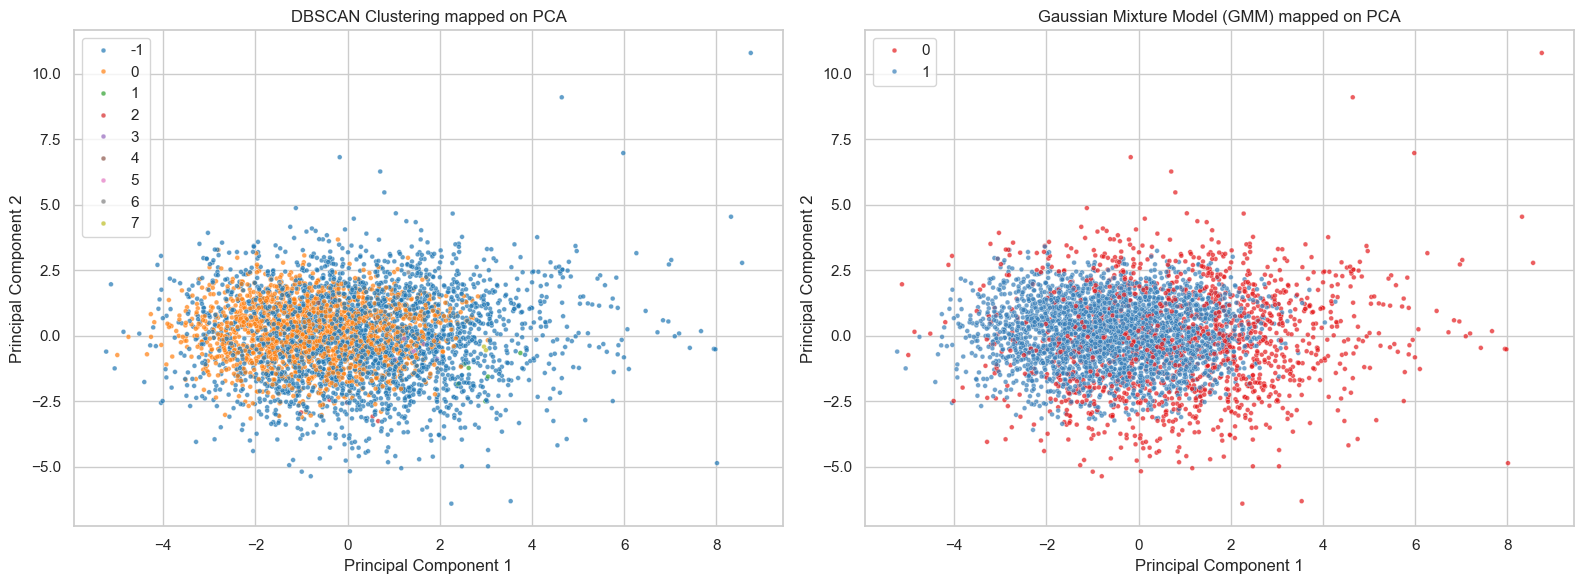

In [49]:
# eps and min_samples might need tuning depending on dataset density
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_sample_unsup)

# Gaussian Mixture Model (GMM) — we assume 2 components (Healthy vs Kidney Disease)
gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
gmm_clusters = gmm.fit(X_unsup_scaled).predict(X_sample_unsup)

# Visualize the clusters using the PCA components derived earlier
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN Plot (-1 indicates noise/outliers)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=dbscan_clusters, palette='tab10', ax=ax[0], alpha=0.7, s=12)
ax[0].set_title('DBSCAN Clustering mapped on PCA')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# GMM Plot
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gmm_clusters, palette='Set1', ax=ax[1], alpha=0.7, s=12)
ax[1].set_title('Gaussian Mixture Model (GMM) mapped on PCA')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')

plt.tight_layout()
save_figure("dbscan_gmm_analysis.png")
plt.show()

* **DBSCAN:** with eps = 2.0 in 17 standardized dimensions it finds one dense core and labels most other patients as noise (−1), giving a negative silhouette (−0.20). The data is a continuous cloud, not separated groups.
* **GMM:** it splits the population into a compact "typical" component and a broad peripheral one (older patients, higher blood pressure, more extreme labs). The low silhouette (0.12) shows these are soft, overlapping groups.

In [50]:
from sklearn.metrics import silhouette_score

print("--- Unsupervised Model Silhouette Scores ---")

# DBSCAN Silhouette Score — requires at least 2 clusters
if len(set(dbscan_clusters)) > 1:
    dbscan_score = silhouette_score(X_sample_unsup, dbscan_clusters)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: N/A (Only one cluster found)")

# GMM Silhouette Score
gmm_score = silhouette_score(X_sample_unsup, gmm_clusters)
print(f"GMM Silhouette Score: {gmm_score:.4f}")

--- Unsupervised Model Silhouette Scores ---


DBSCAN Silhouette Score: -0.1959


GMM Silhouette Score: 0.1234


# KMeans Clustering

### Find Best Cluster Point

Finished k=2 | Score: 0.1269


Finished k=3 | Score: 0.1013


Finished k=4 | Score: 0.0895


Finished k=5 | Score: 0.0845


Finished k=6 | Score: 0.0842


Finished k=7 | Score: 0.0816


Finished k=8 | Score: 0.0828


Finished k=9 | Score: 0.0813


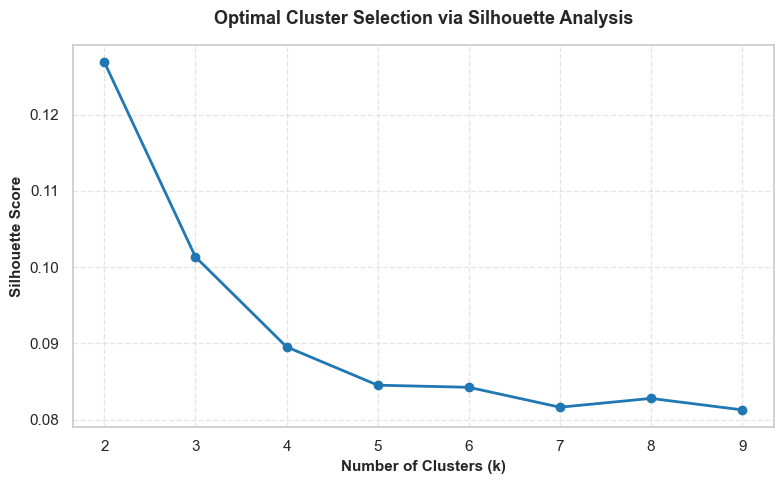

In [51]:
scores = []
for n in range(2, 10):
    km = KMeans(n_clusters=n, random_state=RANDOM_STATE, n_init=20)
    cluster_labels = km.fit_predict(X_sample_unsup)
    score = silhouette_score(X_sample_unsup, cluster_labels)
    scores.append(score)
    print(f"Finished k={n} | Score: {score:.4f}")

cluster_range = range(2, 10)
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, scores, marker='o', linewidth=2, color='#1f77b4', markersize=6)
plt.xlabel("Number of Clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=11, fontweight='bold')
plt.title("Optimal Cluster Selection via Silhouette Analysis", fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### KMeans Clustering

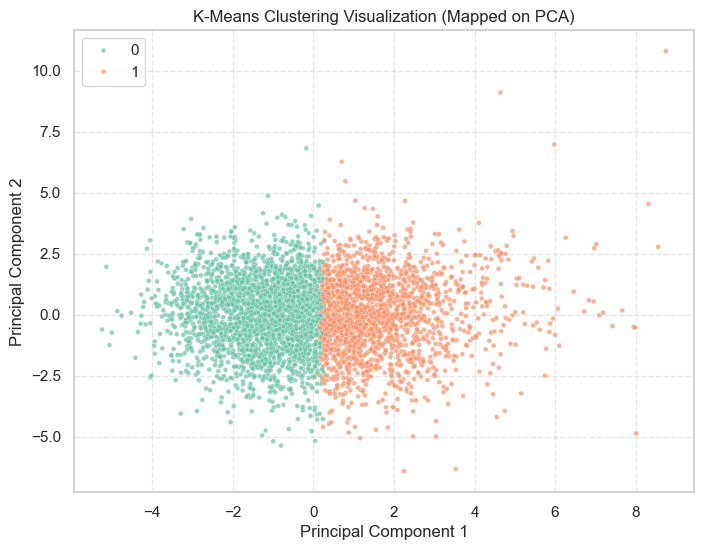

In [52]:
# Run K-Means (Using 2 clusters to see if it separates Healthy vs CKD natively)
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_unsup_scaled)

# Create a copy of the dataframe to store results without warnings
kidney_data_clustered = add_custom_features(kidney_data)
kidney_data_clustered["Cluster"] = kmeans_clusters

plt.figure(figsize=(8, 6))
# We plot using the PCA components derived earlier for a true 2D structural view
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=kmeans_clusters[sample_idx], palette="Set2", alpha=0.7, s=12)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization (Mapped on PCA)")
plt.grid(True, linestyle="--", alpha=0.5)
save_figure("kmeans_clustering.png")
plt.show()

### Cluster Profile

In [53]:
# Look at the average values of the clinical features for each cluster (with the CKD rate)
profile_cols = numerical_features + ['ckd_present']
cluster_profiles = kidney_data_clustered.groupby("Cluster")[profile_cols].mean()
cluster_profiles.loc[:, 'patients'] = kidney_data_clustered['Cluster'].value_counts().sort_index()

# Transpose for easier reading
print("--- Clinical Profile of Each Cluster ---")
display(cluster_profiles.T.round(3))

--- Clinical Profile of Each Cluster ---


Cluster,0,1
age,48.725,61.424
education_level,4.036,3.626
poverty_income_ratio,3.056,2.857
bmi,27.767,32.595
height_cm,167.056,166.766
bp_systolic,111.990,138.090
bp_diastolic,70.180,82.279
blood_urea_nitrogen,14.502,16.135
albumin_serum,4.114,4.002
phosphorus,3.557,3.466


* **Cluster 1 (older, hypertensive, heavier — 2,333 patients):** mean age 61, systolic BP 138, BMI 32.6, higher uric acid; CKD rate **29.8 %**.
* **Cluster 0 (younger, normotensive — 3,140 patients):** mean age 49, systolic BP 112, BMI 27.8; CKD rate **11.4 %**.

**Takeaway:** without seeing the label, K-Means split patients along the cardio-metabolic axis (age, blood pressure, BMI), and CKD is 2.6× more common in the high-risk cluster — the same risk factors the supervised model relies on.

# Anomaly Detection
DBSCAN finds noisy points only as a side effect; anomaly detectors are built specifically to find extreme clinical anomalies (patients with highly unusual feature combinations).

* **One-Class SVM:** Learns a soft boundary around the majority of the data without assuming a specific distribution.

* **Elliptic Envelope:** Assumes the data is roughly Gaussian (normally distributed) and draws an elliptical boundary from the data's variance.

* **Isolation Forest:** Isolates points by randomly selecting and splitting features; anomalies need fewer splits to isolate.

* **ECOD:** Flags outliers from the empirical cumulative distribution of each dimension, with no parameters to tune.

* **COPOD:** Models the joint distribution with copulas and flags points in the low-probability tails.

* **Autoencoder:** A neural network that learns to compress and reconstruct normal data; anomalies have high reconstruction errors.

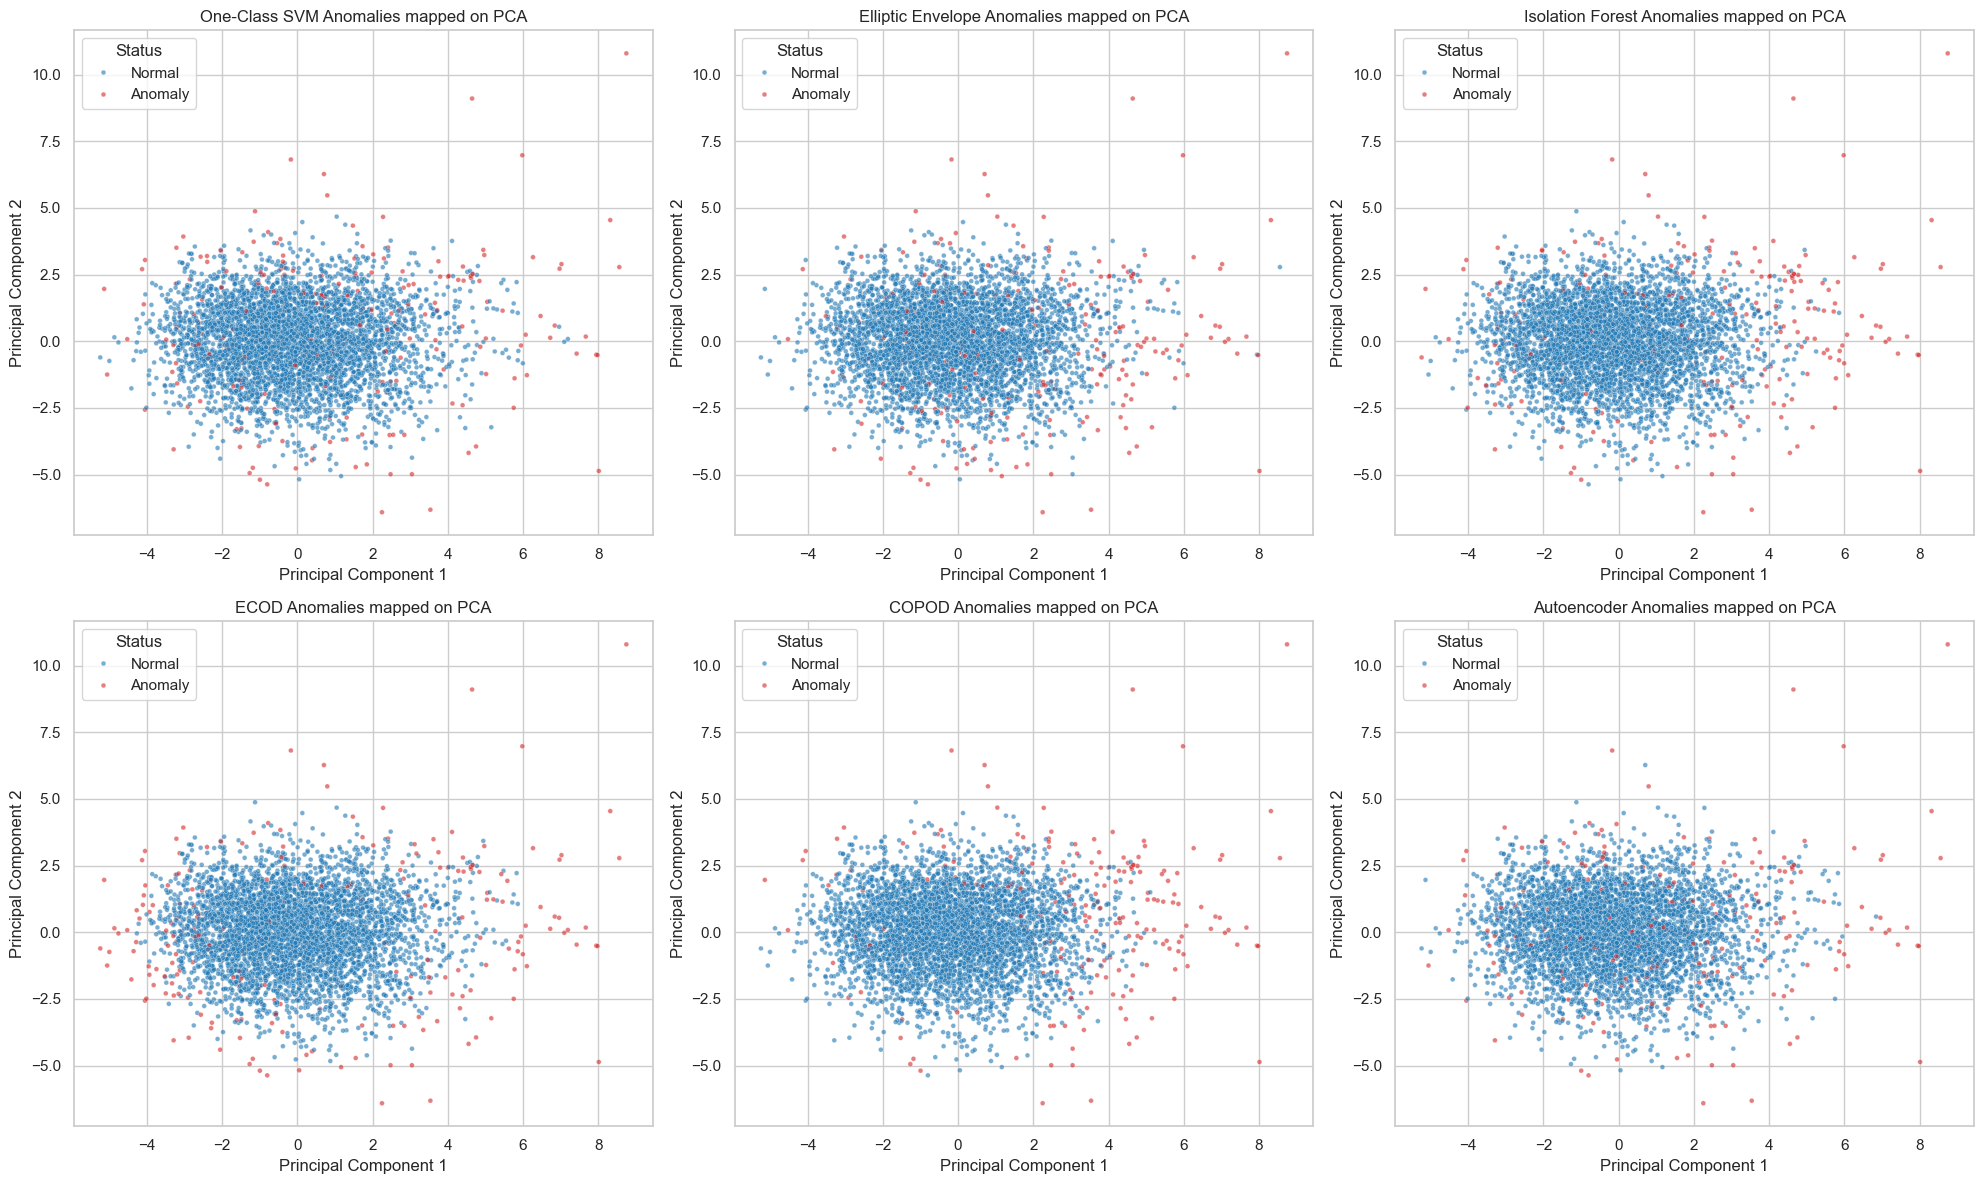

In [54]:
# On Colab: !pip install -q pyod
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.auto_encoder import AutoEncoder

# We will assume around 5% of our patient records might be extreme clinical anomalies (contamination / nu)
anomaly_fraction = 0.05

# One-Class SVM
oc_svm = OneClassSVM(nu=anomaly_fraction, kernel="rbf", gamma="scale")
svm_anomalies = oc_svm.fit_predict(X_unsup_scaled)  # Returns -1 for anomalies, 1 for normal

# Elliptic Envelope
elliptic = EllipticEnvelope(contamination=anomaly_fraction, random_state=RANDOM_STATE)
ee_anomalies = elliptic.fit_predict(X_unsup_scaled)

# Isolation Forest
iso_forest = IsolationForest(contamination=anomaly_fraction, random_state=RANDOM_STATE)
if_anomalies = iso_forest.fit_predict(X_unsup_scaled)

# ECOD — PyOD returns 1 for anomaly, 0 for normal. Mapping to -1 and 1 for consistency.
ecod = ECOD(contamination=anomaly_fraction)
ecod.fit(X_unsup_scaled)
ecod_anomalies = np.where(ecod.labels_ == 1, -1, 1)

# COPOD
copod = COPOD(contamination=anomaly_fraction)
copod.fit(X_unsup_scaled)
copod_anomalies = np.where(copod.labels_ == 1, -1, 1)

# Autoencoder
with silenced():
    ae = AutoEncoder(contamination=anomaly_fraction, random_state=RANDOM_STATE, verbose=0)
    ae.fit(X_unsup_scaled)
ae_anomalies = np.where(ae.labels_ == 1, -1, 1)

models_results = [
    ('One-Class SVM', svm_anomalies),
    ('Elliptic Envelope', ee_anomalies),
    ('Isolation Forest', if_anomalies),
    ('ECOD', ecod_anomalies),
    ('COPOD', copod_anomalies),
    ('Autoencoder', ae_anomalies)
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ax = axes.flatten()
for i, (title, anomalies) in enumerate(models_results):
    status = np.where(anomalies[sample_idx] == -1, 'Anomaly', 'Normal')
    sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=status, hue_order=['Normal', 'Anomaly'],
                    palette={'Normal': '#1f77b4', 'Anomaly': '#d62728'}, ax=ax[i], alpha=0.6, s=12)
    ax[i].set_title(f'{title} Anomalies mapped on PCA')
    ax[i].set_xlabel('Principal Component 1')
    ax[i].set_ylabel('Principal Component 2')
    ax[i].legend(title='Status')

plt.tight_layout()
save_figure("anomaly_detection_models.png")
plt.show()

1. **Where the anomalies are:** all six detectors flag the sparse outer points of the PCA cloud (red), far from the dense center (blue).
2. **Agreement:** the detectors agree on the most extreme patients and differ at the border of the main cloud, reflecting their different assumptions (tree splits, density, copulas, reconstruction error).
3. **Consensus** across detectors is more robust than any single one — see the counts below.

In [55]:
anomaly_counts = []
ckd_flags = kidney_data['ckd_present'].values == 1

for title, anomalies in models_results:
    anomaly_count = (anomalies == -1).sum()
    anomaly_counts.append({
        'Model': title,
        'Anomalies Detected': anomaly_count,
        'Normal Patients': (anomalies == 1).sum(),
        'Anomaly %': f"{anomaly_count / len(anomalies) * 100:.2f}%",
        'CKD rate among anomalies': f"{ckd_flags[anomalies == -1].mean() * 100:.1f}%"
    })

df_anomaly_comp = pd.DataFrame(anomaly_counts).set_index('Model')
print("=== Anomaly Detection Counts ===")
display(df_anomaly_comp)

# --- Consensus Calculation ---
all_anomalies = np.vstack([anomalies for _, anomalies in models_results])
times_flagged = (all_anomalies == -1).sum(axis=0)

print("\n=== Anomaly Consensus ===")
print(f"Patients flagged by at least 1 model: {(times_flagged >= 1).sum()}")
print(f"Patients flagged by majority (>= 3 models): {(times_flagged >= 3).sum()}")
print(f"Patients flagged by ALL 6 models (Strict Consensus): {(times_flagged == 6).sum()}")
print(f"\nOverall CKD prevalence: {ckd_flags.mean():.1%} | among strict-consensus anomalies: {ckd_flags[times_flagged == 6].mean():.1%}")

=== Anomaly Detection Counts ===


,Anomalies Detected,Normal Patients,Anomaly %,CKD rate among anomalies
Model,,,,
One-Class SVM,273,5200,4.99%,46.5%
Elliptic Envelope,274,5199,5.01%,46.4%
Isolation Forest,274,5199,5.01%,55.5%
ECOD,274,5199,5.01%,44.5%
COPOD,274,5199,5.01%,53.6%
Autoencoder,274,5199,5.01%,44.5%



=== Anomaly Consensus ===
Patients flagged by at least 1 model: 603
Patients flagged by majority (>= 3 models): 264
Patients flagged by ALL 6 models (Strict Consensus): 76

Overall CKD prevalence: 19.3% | among strict-consensus anomalies: 64.5%


* 603 patients are flagged by at least one detector, 264 by a majority and 76 by all six.
* **The anomalies are mostly sick patients:** the CKD rate among flagged patients is 45–56 % per detector and 64.5 % in the strict consensus, against 19.3 % overall. Extreme kidney labs *are* the disease, so a gate that withholds predictions from anomalies turns away exactly the patients a screening tool exists for. This is why the cascade below uses a narrow 1 % gate and measures who it withholds.

# Cascade Architechture

### Kidney Disease Cascade Architecture

The cascade maximizes clinical safety and model reliability:

1. **Stage 1 (Anomaly Flagging):** An **Isolation Forest** catches patients with implausible or extreme profiles (data-entry errors, rare compounding conditions). They go to manual clinical review instead of receiving a prediction. Two changes from the original: the gate is fitted on the **training set only** (not on all data including the test set), and its contamination is **1 %** rather than 5 %, because the anomaly analysis above shows that much of what a wider gate removes is disease itself. The check below measures how often CKD and non-CKD patients are withheld.
2. **Stage 2 (Supervised Classification):** Patients who pass Stage 1 are scored by the **calibrated best model**. The out-of-fold cost-optimal threshold decides "order kidney tests", and risk bands are anchored to it: **Low** (below the threshold), **Medium** (threshold to 50 %), **High** (≥ 50 %).

In [56]:
# Stage 1 gate: numeric features only, fitted on the TRAINING set
anomaly_gate = Pipeline(steps=[
    ('engineering', FunctionTransformer(add_custom_features)),
    ('select', ColumnTransformer([('numeric', 'passthrough', numerical_features)])),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('detector', IsolationForest(n_estimators=200, contamination=0.01, random_state=RANDOM_STATE))
])
anomaly_gate.fit(X_train)

gate_flags = anomaly_gate.predict(X_test) == -1
print(f"Test patients withheld by the gate: {gate_flags.sum()} ({gate_flags.mean():.2%})")
print(f"  among CKD patients    : {gate_flags[y_test.values == 1].mean():.2%}")
print(f"  among non-CKD         : {gate_flags[y_test.values == 0].mean():.2%}")

Test patients withheld by the gate: 18 (1.64%)
  among CKD patients    : 6.16%
  among non-CKD         : 0.57%


* The 1 % gate withholds 18 of 1,095 test patients (1.6 %), but **CKD patients are about 11× more likely to be withheld than healthy ones (6.2 % vs 0.6 %)**: advanced kidney disease produces lab values at the edge of the training distribution. The high-risk mock patient in the final test is withheld for the same reason.
* A withheld patient is not told they are healthy — they are routed to manual clinical review, a safe outcome for someone this sick. It does mean the gate is more than a data-entry check. If every plausible patient should receive a score, withhold only physiologically impossible values (range checks) and report the Isolation Forest result as an "unusual profile" flag instead.

In [57]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP explainer for patient-level explanations (same model type logic as above)
cascade_explainer = build_shap_explainer(model_object, background)

def kidney_evaluation(patients_data, model=calibrated_clf, anomaly_model=anomaly_gate, threshold=best_threshold,
                      patient_names=None, explain=True):
    # --- STAGE 1: Anomaly Detection ---
    anomalies = anomaly_model.predict(patients_data) if anomaly_model is not None else None

    # Let the AI calculate its calibrated CKD probability (%)
    prediction_probabilities = model.predict_proba(patients_data)[:, 1]

    # If explanations are requested, prepare SHAP components
    if explain:
        X_processed = preprocessor.transform(patients_data)
        patient_shap = compute_shap(cascade_explainer, X_processed)

    for i in range(len(patients_data)):
        name = patient_names[i] if patient_names else f"Patient {i+1}"
        print(f"=== Diagnostic Results for {name} ===")

        # --- STAGE 1 CHECK ---
        if anomalies is not None and anomalies[i] == -1:
            print("🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!")
            print("Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.\n")
            continue # Skip Stage 2 entirely

        # --- STAGE 2: CLASSIFICATION ---
        p = prediction_probabilities[i]

        # Custom Risk Stratification Logic, anchored to the cost-optimal threshold
        if p < threshold:
            risk_level = "Low Risk"
        elif p < 0.50:
            risk_level = "Medium Risk"
        else:
            risk_level = "High Risk"

        print(f"Kidney Disease Probability : {p * 100:.2f}%")
        print(f"Risk Categorization        : {risk_level}")
        print(f"Recommendation             : {'Order eGFR + urine ACR tests' if p >= threshold else 'Routine care'}")

        if explain:          # Add Text-based SHAP Explanations
            print("\nExplanation:")
            explanation = shap.Explanation(
                values=patient_shap.values[i],
                base_values=np.ravel(patient_shap.base_values)[i] if np.ndim(patient_shap.base_values) else patient_shap.base_values,
                data=X_processed[i],
                feature_names=feature_names
            )

            # Sort features by absolute SHAP value to find top contributors
            sorted_indices = np.argsort(np.abs(explanation.values))[::-1]
            print("Top Contributing Factors:")
            for rank, idx in enumerate(sorted_indices[:4]):
                print(f"{rank+1}. {feature_names[idx].replace('_', ' ').title()} ({explanation.values[idx]:+.2f})")

            # Generate and display Waterfall Plot
            print(f"\nWaterfall Plot for {name}:")
            plt.figure(figsize=(8, 6), dpi=100)
            shap.plots.waterfall(explanation, max_display=10, show=False)
            plt.title(f'SHAP Waterfall Plot for {name}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        print("\n" + "="*50 + "\n")

We enhanced the cascade architecture by embedding SHAP (SHapley Additive exPlanations) directly into the evaluation function.

# Ai Prediction Test

=== Diagnostic Results for Patient A (Index 4866, true label: No CKD) ===
Kidney Disease Probability : 0.63%
Risk Categorization        : Low Risk
Recommendation             : Routine care

Explanation:
Top Contributing Factors:
1. Age (-2.09)
2. Bicarbonate (-0.61)
3. Blood Urea Nitrogen (-0.28)
4. Calcium (-0.28)

Waterfall Plot for Patient A (Index 4866, true label: No CKD):


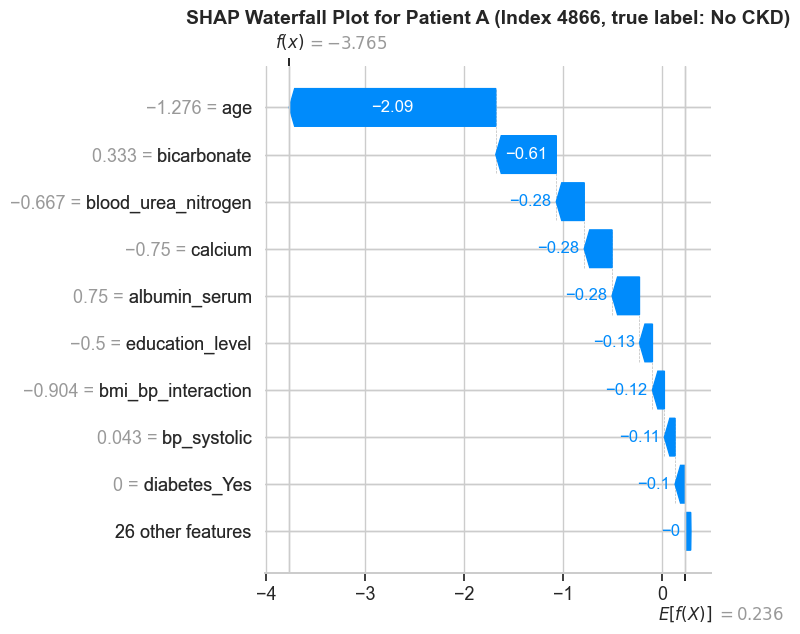



=== Diagnostic Results for Patient B (Index 600, true label: No CKD) ===
Kidney Disease Probability : 13.51%
Risk Categorization        : Low Risk
Recommendation             : Routine care

Explanation:
Top Contributing Factors:
1. Age (+0.86)
2. Blood Urea Nitrogen (-0.62)
3. Height Cm (-0.46)
4. Calcium (-0.39)

Waterfall Plot for Patient B (Index 600, true label: No CKD):


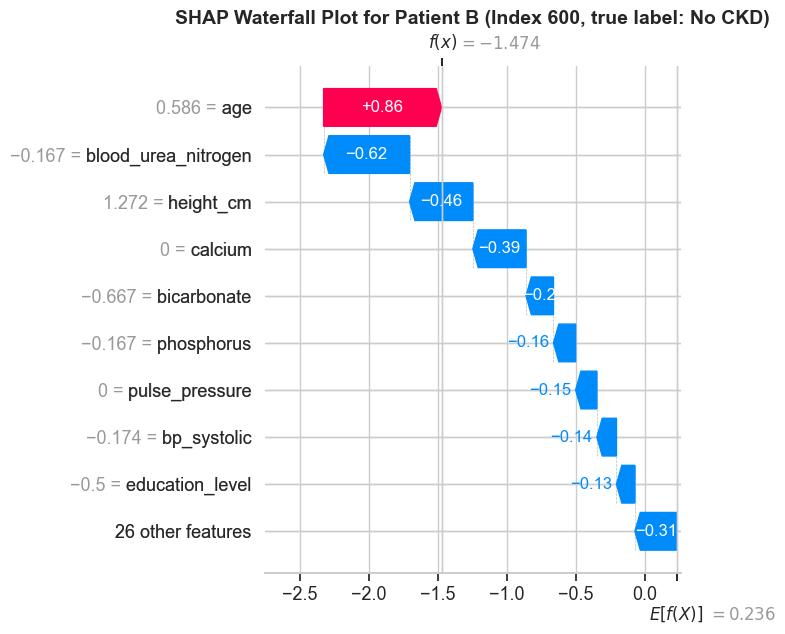



=== Diagnostic Results for Patient C (Index 8998, true label: No CKD) ===
Kidney Disease Probability : 10.92%
Risk Categorization        : Low Risk
Recommendation             : Routine care

Explanation:
Top Contributing Factors:
1. Age (-0.92)
2. Education Level (-0.38)
3. Blood Urea Nitrogen (-0.27)
4. Calcium (-0.17)

Waterfall Plot for Patient C (Index 8998, true label: No CKD):


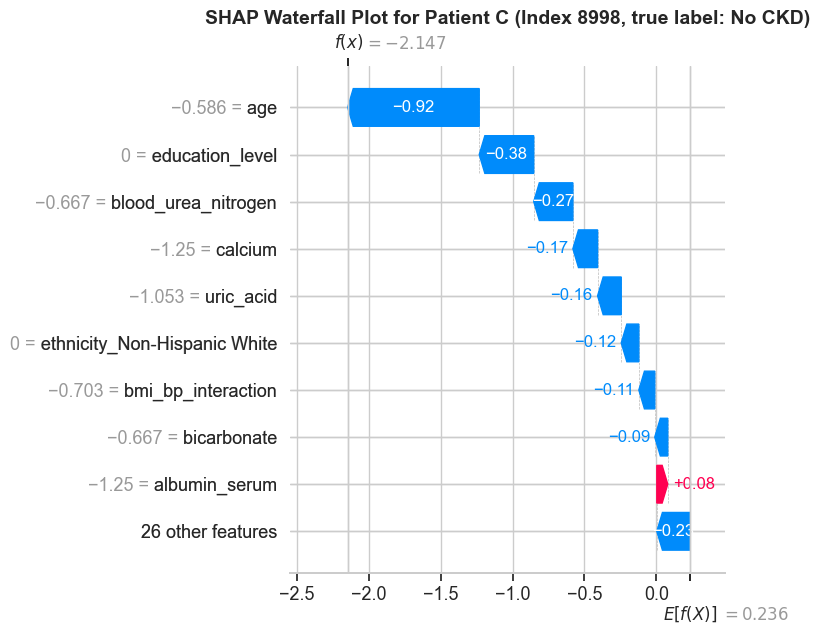

In [58]:
# Let's test the evaluation function on the first 3 patients in the test set!
sample_patients = X_test.head(3)
sample_names = [f"Patient {chr(65 + i)} (Index {idx}, true label: {'CKD' if y_test.loc[idx] else 'No CKD'})"
                for i, idx in enumerate(sample_patients.index)]

kidney_evaluation(sample_patients, patient_names=sample_names, explain=True)

# Save and Test Final Model (Joblib)
We save the calibrated model, the Stage 1 anomaly gate and a `metadata.json` (threshold, feature lists) to `models/`, then reload them and test with mock patients.

*Note:* the pipelines reference `add_custom_features`, defined in this notebook. `src/train.py` re-trains the same pipeline with an importable version of the function, and those are the artifacts `src/predict.py` serves.

In [59]:
import joblib

model_filename = os.path.join(models_dir, "kidney_disease_calibrated_model.joblib")
gate_filename = os.path.join(models_dir, "kidney_anomaly_gate.joblib")
metadata_filename = os.path.join(models_dir, "metadata.json")

joblib.dump(calibrated_clf, model_filename)
joblib.dump(anomaly_gate, gate_filename)

metadata = {
    'best_model': best_model_name,
    'selection_rule': 'one-standard-error rule on 5-fold CV PR-AUC',
    'target': 'KDIGO: eGFR < 60 or urine ACR >= 30 (adults 20+)',
    'removed_label_defining_features': label_defining_features,
    'optimal_threshold': best_threshold,
    'cost_weights': {'false_negative': FN_COST, 'false_positive': FP_COST},
    'risk_bands': {'low': f'< {best_threshold:.4f}', 'medium': f'{best_threshold:.4f} - 0.50', 'high': '>= 0.50'},
    'raw_input_columns': X.columns.tolist(),
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'test_metrics': {'roc_auc': roc_auc_score(y_test, calib_probas), 'pr_auc': average_precision_score(y_test, calib_probas),
                     'brier_score': brier_calibrated, 'recall_at_threshold': recall_score(y_test, sim_preds_best),
                     'precision_at_threshold': precision_score(y_test, sim_preds_best)},
    'bootstrap_confidence_intervals': confidence_intervals,
    'training_rows': len(X_train), 'test_rows': len(X_test), 'prevalence': float(y.mean())
}
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2, default=float)

print(f"[SAVED] Calibrated Model successfully saved to:\n{model_filename}")
print(f"[SAVED] Anomaly Gate -> {gate_filename}")
print(f"[SAVED] Metadata     -> {metadata_filename}")

[SAVED] Calibrated Model successfully saved to:
E:\Disease-Risk-Prediction\kidney\tabuler\models\kidney_disease_calibrated_model.joblib
[SAVED] Anomaly Gate -> E:\Disease-Risk-Prediction\kidney\tabuler\models\kidney_anomaly_gate.joblib
[SAVED] Metadata     -> E:\Disease-Risk-Prediction\kidney\tabuler\models\metadata.json



[LOADED] Successfully loaded model from E:\Disease-Risk-Prediction\kidney\tabuler\models\kidney_disease_calibrated_model.joblib



=== Loaded Joblib Model Test ===


=== Diagnostic Results for Patient A (High Risk Mock) ===
🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!
Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.

=== Diagnostic Results for Patient B (Low Risk Mock) ===
Kidney Disease Probability : 3.19%
Risk Categorization        : Low Risk
Recommendation             : Routine care

Explanation:
Top Contributing Factors:
1. Age (-0.94)
2. Education Level (-0.62)
3. Blood Urea Nitrogen (-0.26)
4. Calcium (-0.18)

Waterfall Plot for Patient B (Low Risk Mock):


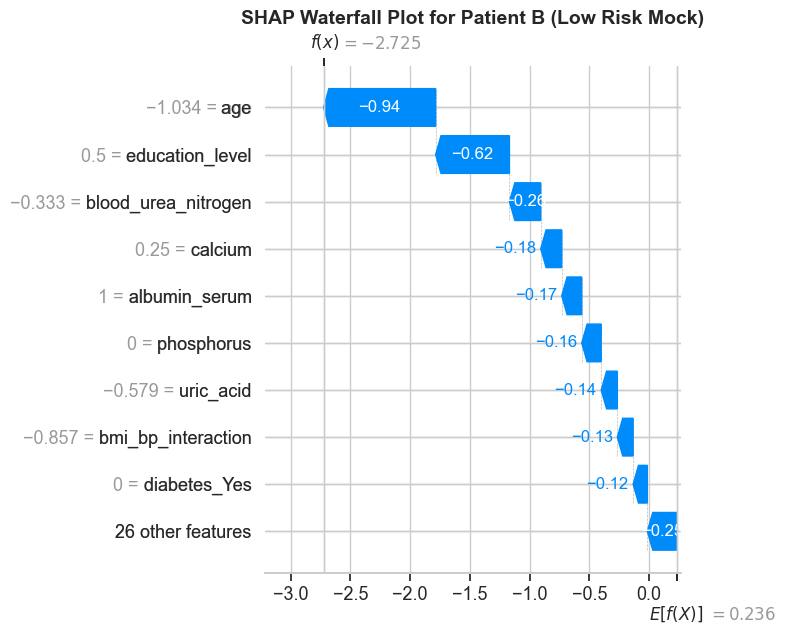



=== Diagnostic Results for Patient C (Extreme Anomaly Mock) ===
🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!
Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.



In [60]:
import pandas as pd

# Test with mock patients
loaded_model = joblib.load(model_filename)
loaded_gate = joblib.load(gate_filename)
print(f"\n[LOADED] Successfully loaded model from {model_filename}")

mock_patients = pd.DataFrame([
    {
        # Patient A (High Risk Mock: elderly, insulin-treated diabetes, hypertension, high BUN / uric acid)
        "age": 74.0, "gender": "Male", "ethnicity": "Non-Hispanic Black", "education_level": 2.0, "poverty_income_ratio": 1.2,
        "bmi": 33.0, "weight_kg": 97.0, "height_cm": 172.0, "bp_systolic": 168.0, "bp_diastolic": 92.0,
        "blood_urea_nitrogen": 38.0, "albumin_serum": 3.5, "phosphorus": 4.6, "bicarbonate": 21.0,
        "calcium": 9.0, "uric_acid": 8.4, "diabetes": "Yes", "insulin_use": "Yes", "diabetes_pills": "Yes",
        "smoking_status": "Former"
    },
    {
        # Patient B (Low Risk Mock: young, normal blood pressure and labs, no diabetes)
        "age": 28.0, "gender": "Female", "ethnicity": "Non-Hispanic Asian", "education_level": 5.0, "poverty_income_ratio": 4.5,
        "bmi": 22.0, "weight_kg": 60.0, "height_cm": 165.0, "bp_systolic": 110.0, "bp_diastolic": 70.0,
        "blood_urea_nitrogen": 12.0, "albumin_serum": 4.5, "phosphorus": 3.5, "bicarbonate": 24.0,
        "calcium": 9.5, "uric_acid": 4.0, "diabetes": "No", "insulin_use": "No", "diabetes_pills": "No",
        "smoking_status": "Never"
    },
    {
        # Patient C (Extreme Anomaly Mock: Impossible values to trigger Stage 1 Rejection)
        "age": 150.0, "gender": "Male", "ethnicity": "Other Hispanic", "education_level": 1.0, "poverty_income_ratio": 0.1,
        "bmi": 100.0, "weight_kg": 625.0, "height_cm": 250.0, "bp_systolic": 300.0, "bp_diastolic": 200.0,
        "blood_urea_nitrogen": 200.0, "albumin_serum": 1.0, "phosphorus": 15.0, "bicarbonate": 5.0,
        "calcium": 15.0, "uric_acid": 20.0, "diabetes": "Yes", "insulin_use": "Yes", "diabetes_pills": "Yes",
        "smoking_status": "Current"
    }
])[X.columns]

print("\n=== Loaded Joblib Model Test ===")
kidney_evaluation(
    patients_data=mock_patients,
    model=loaded_model,
    anomaly_model=loaded_gate,
    patient_names=["Patient A (High Risk Mock)", "Patient B (Low Risk Mock)", "Patient C (Extreme Anomaly Mock)"]
)

# Conclusion
This notebook rebuilt the kidney (CKD) pipeline around a correct, leakage-free target and benchmarked 17 classifiers — the original nine plus eight modern tabular models — under one cross-validation protocol.

**Key Achievements & Methodologies:**
* **Target audit & correction:** the raw export labelled 5,607 unknown-status participants (mostly children) and everyone with eGFR 60–89 as CKD, so the original ~99 % scores measured age and missing labs. The target was rebuilt with the KDIGO definition (eGFR < 60 or ACR ≥ 30) for 5,473 adults (19.3 % CKD), and the five label-defining lab values were removed from the inputs.
* **Leakage-aware preprocessing:** NHANES codes and skip-patterns resolved, scaling before KNN imputation, SMOTENC before one-hot encoding, oversampling tuned per model, and every fitted step inside the cross-validation pipeline.
* **Model benchmark:** TabPFN reached the best CV PR-AUC (0.632), with LightGBM, Stacking, CatBoost and XGBoost statistically tied. The one-standard-error rule selected **LightGBM** (CV PR-AUC 0.629, test ROC-AUC 0.829). The deep tabular models (TabM, FT-Transformer, RealMLP, TabNet) did not beat boosted trees on 4,378 training rows.
* **Calibration & clinical threshold:** isotonic calibration removed SMOTE's over-prediction (Brier score 0.116 → 0.110; always-predict-prevalence reference 0.156). The cost-optimal threshold chosen on out-of-fold training data (0.175, next to the Bayes-optimal 0.167) gives **recall 0.75 (95 % CI 0.70–0.81)** and precision 0.40 on the untouched test set, with ROC-AUC 0.834 (0.802–0.863).
* **Explainability:** SHAP and permutation importance agree that age, blood urea nitrogen, bicarbonate, uric acid, blood pressure, diabetes and socioeconomic status drive the predictions — clinically sensible markers, none of them label-defining.
* **Unsupervised insights:** K-Means separates a cardio-metabolic high-risk group (CKD 29.8 % vs 11.4 %), and anomaly detectors mostly flag CKD patients (64.5 % CKD in the strict consensus) because extreme labs are the disease itself.
* **Explainable cascade:** Stage 1 (1 % Isolation Forest, fitted on training data only) routes 1.6 % of patients to manual review, mostly advanced CKD. Stage 2 returns a calibrated probability, a risk band, a referral decision (order eGFR + urine ACR) and a SHAP explanation.

**Future Work / Next Steps:**
* **More data:** adding the 2007–2020 NHANES cycles would raise the number of CKD cases from about 1,000 to several thousand and tighten the confidence intervals.
* **Plausibility-based Stage 1:** complement the Isolation Forest with physiological range checks so that severe-but-real patients still receive a score.
* **External validation:** test on hospital records, where CKD prevalence and lab-ordering patterns differ from a population survey.